# fMRI Block Design Simulation: Comparing Design Strategies

This notebook simulates fMRI task data with **6 events** (block design) and compares how well different **experimental designs** recover the true beta values.

## Key Features:
- **Multi-run framework**: Simulate N runs with identical design, independent noise
- **Modular design system**: Easy to add new designs via registry
- **Colored noise**: 1/f^α power spectrum via FFT (realistic fMRI noise)
- **Block-diagonal polynomials**: Proper per-run drift modeling in GLM
- **Two GLM approaches**: Multi-run concatenated vs run-averaged
- **HRF mismatch testing**: Simulate with one HRF, recover with another
- **TSNR guidance**: Understand noise level in real-world terms

## Designs Included:
1. **Fixed Blocks**: Events cycle 1→2→3→4→5→6 with fixed ISI
2. **Jittered ISI**: Events in random order, ISI sampled from Gaussian
3. **Mirrored Order**: 1-2-3-4-5-6 → gap → 6-5-4-3-2-1 → gap → repeat

In [156]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import torch
import matplotlib.pyplot as plt
import fastfuncsim as ffs
from typing import Dict, Tuple, List, Callable

np.set_printoptions(precision=4, suppress=True)
torch.set_printoptions(precision=4, sci_mode=False)

device = ffs.get_device()
print(f"Using device: {device}")

Using device: cuda


## Simulation Parameters

In [157]:
# =============================================================================
# SIMULATION PARAMETERS
# =============================================================================

# Multi-run structure
N_RUNS = 7                  # Number of runs (like separate fMRI scans)
N_REPEATS_PER_RUN = 2       # Cycles through all events PER RUN

# Timing
TR = 2.5                    # Repetition time (seconds)
STIM_DURATION = 10.0        # Block duration (seconds)
N_EVENTS = 6                # Number of event types
INITIAL_DELAY = 10.0        # Seconds before first event (baseline, T1 equilibration)
POST_DELAY = 15.0           # Seconds after last event (allow HRF to return to baseline)

# True effect sizes (betas)
TRUE_BETAS = [0.5, 1.0, 1.5, 2.5, 3.0, 5.0]

# Noise parameters
NOISE_LEVEL = 2             # Noise amplitude relative to signal (see TSNR cell below)
PINK_EXPONENT = 1.0         # 1/f^α noise (1.0 = pink, 0 = white, 2 = brown)

# Polynomial drift order for GLM (per run)
POLY_ORDER = 3              # 0=mean, 1=linear, 2=quadratic, etc.

# HRF settings
USE_DIFFERENT_HRF = True    # If True, simulate with library HRF, recover with canonical
SIMULATION_HRF_INDEX = 12   # Which HRF from library to use (0-19, ignored if USE_DIFFERENT_HRF=False)

# Simulation
N_VOXELS = 1000
SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"TR: {TR}s")
print(f"Stimulus duration: {STIM_DURATION}s ({STIM_DURATION/TR:.1f} TRs)")
print(f"Events: {N_EVENTS}")
print(f"Runs: {N_RUNS}, Repeats per run: {N_REPEATS_PER_RUN}")
print(f"Total repeats per condition: {N_RUNS * N_REPEATS_PER_RUN}")
print(f"Initial delay: {INITIAL_DELAY}s, Post delay: {POST_DELAY}s")
print(f"True betas: {TRUE_BETAS}")
print(f"Noise: level={NOISE_LEVEL}, 1/f exponent={PINK_EXPONENT}")
print(f"Polynomial drift order: {POLY_ORDER} per run")
print(f"HRF mismatch: {USE_DIFFERENT_HRF}")

TR: 2.5s
Stimulus duration: 10.0s (4.0 TRs)
Events: 6
Runs: 7, Repeats per run: 2
Total repeats per condition: 14
Initial delay: 10.0s, Post delay: 15.0s
True betas: [0.5, 1.0, 1.5, 2.5, 3.0, 5.0]
Noise: level=2, 1/f exponent=1.0
Polynomial drift order: 3 per run
HRF mismatch: True


<cell_type>markdown</cell_type>## Understanding TSNR and Noise Calibration

**TSNR (Temporal Signal-to-Noise Ratio)** = mean / std of the signal over time.

For a baseline signal of 100:
- TSNR = 100 means std = 1 (very clean)
- TSNR = 50 means std = 2 (typical good quality)
- TSNR = 20 means std = 5 (noisy)

**Key Point**: TSNR is calculated from baseline + noise, ignoring BOLD fluctuations. This is different from CNR (Contrast-to-Noise Ratio) which involves the BOLD signal change.

The cell below provides:
1. `calculate_noise_level_for_tsnr(target_tsnr)` - Get the noise scale for a target TSNR
2. `verify_tsnr(noise_scale)` - Verify the achieved TSNR
3. A calibration table showing noise scales for common TSNR values

**Typical real fMRI TSNR values:**
- 7T high-res: TSNR = 30-60
- 3T standard: TSNR = 50-100
- 3T optimized: TSNR = 100-150

In [158]:
# =============================================================================
# TSNR-Based Noise Calibration
# =============================================================================
# 
# TSNR (Temporal Signal-to-Noise Ratio) = mean / std of the signal
# For a baseline of 100 (typical fMRI), if TSNR = 50, then std = 100/50 = 2
#
# This is DIFFERENT from CNR (Contrast-to-Noise Ratio) which involves BOLD change.
# Here we calibrate noise to match a target TSNR, ignoring the BOLD signal.

def calculate_noise_level_for_tsnr(target_tsnr: float, 
                                    baseline: float = 100.0,
                                    tr: float = TR,
                                    duration_s: float = 300.0,
                                    pink_exp: float = PINK_EXPONENT,
                                    n_samples: int = 100) -> float:
    """
    Find the noise scaling factor that produces a target TSNR.
    
    TSNR = mean(signal) / std(signal)
    For baseline-only signal: TSNR = baseline / std(noise)
    So: std(noise) = baseline / target_tsnr
    
    We need to find what scaling factor produces this std for our colored noise.
    
    Args:
        target_tsnr: Desired TSNR value
        baseline: Mean signal level (default 100)
        tr: Repetition time
        duration_s: Duration for testing
        pink_exp: 1/f^α exponent
        n_samples: Number of samples for averaging
    
    Returns:
        noise_scale: The scaling factor to apply to normalized noise
    """
    # Target noise std based on TSNR definition
    target_noise_std = baseline / target_tsnr
    
    # Generate sample noise to measure its std when normalized
    noise_stds = []
    
    for _ in range(n_samples):
        noise = ffs.generate_fmri_noise(
            tr=tr, duration_s=duration_s, matrix_size=(1, 1),
            pink_exp=pink_exp, resp_strength=0.0, cardiac_strength=0.0,
            normalize=True, device=device
        ).cpu().numpy().flatten()
        noise_stds.append(noise.std())
    
    # The normalized noise has this average std
    normalized_noise_std = np.mean(noise_stds)
    
    # To achieve target_noise_std, we need to scale by:
    noise_scale = target_noise_std / normalized_noise_std
    
    return noise_scale


def verify_tsnr(noise_scale: float, 
                baseline: float = 100.0,
                tr: float = TR,
                duration_s: float = 300.0,
                pink_exp: float = PINK_EXPONENT,
                n_samples: int = 100) -> Tuple[float, float]:
    """
    Verify the TSNR produced by a given noise scale.
    Simulates baseline + noise (no BOLD signal) and measures TSNR.
    """
    tsnrs = []
    
    for _ in range(n_samples):
        noise = ffs.generate_fmri_noise(
            tr=tr, duration_s=duration_s, matrix_size=(1, 1),
            pink_exp=pink_exp, resp_strength=0.0, cardiac_strength=0.0,
            normalize=True, device=device
        ).cpu().numpy().flatten()
        
        # Simulate: baseline + scaled noise
        signal = baseline + noise * noise_scale
        
        # Measure TSNR
        tsnr = signal.mean() / signal.std()
        tsnrs.append(tsnr)
    
    return np.mean(tsnrs), np.std(tsnrs)


print("TSNR Calibration Table")
print("=" * 70)
print(f"Baseline: 100.0, Noise type: 1/f^{PINK_EXPONENT}")
print()

# Test a range of target TSNRs
target_tsnrs = [150, 100, 75, 50, 30, 20, 10]

print(f"{'Target TSNR':>12} {'Noise Scale':>15} {'Achieved TSNR':>18}")
print("-" * 50)

for target_tsnr in target_tsnrs:
    noise_scale = calculate_noise_level_for_tsnr(target_tsnr)
    achieved_tsnr, tsnr_std = verify_tsnr(noise_scale)
    print(f"{target_tsnr:>12} {noise_scale:>15.3f} {achieved_tsnr:>12.1f} ± {tsnr_std:.1f}")

print()
print("=" * 70)
print("Usage: Set NOISE_LEVEL = calculate_noise_level_for_tsnr(target_tsnr)")
print("  Example: NOISE_LEVEL = calculate_noise_level_for_tsnr(50)")
print()
print("Note: Current NOISE_LEVEL is relative to BOLD signal std, not baseline.")
print("The table above gives noise scales relative to baseline (100).")
print("=" * 70)
print()
print("Typical real fMRI TSNR values:")
print("  - 7T high-res: TSNR = 30-60")
print("  - 3T standard: TSNR = 50-100")  
print("  - 3T optimized: TSNR = 100-150")

TSNR Calibration Table
Baseline: 100.0, Noise type: 1/f^1.0

 Target TSNR     Noise Scale      Achieved TSNR
--------------------------------------------------
         150           0.669        150.0 ± 0.0
         100           1.004        100.0 ± 0.0
          75           1.339         75.0 ± 0.0
          50           2.008         50.0 ± 0.0
          30           3.347         30.0 ± 0.0
          20           5.021         20.0 ± 0.0
          10          10.042         10.0 ± 0.0

Usage: Set NOISE_LEVEL = calculate_noise_level_for_tsnr(target_tsnr)
  Example: NOISE_LEVEL = calculate_noise_level_for_tsnr(50)

Note: Current NOISE_LEVEL is relative to BOLD signal std, not baseline.
The table above gives noise scales relative to baseline (100).

Typical real fMRI TSNR values:
  - 7T high-res: TSNR = 30-60
  - 3T standard: TSNR = 50-100
  - 3T optimized: TSNR = 100-150


## Design Registry

Each design is a function that returns `(onsets, onset_times_dict)`. To add a new design, just define a function and add it to `DESIGN_REGISTRY`.

In [159]:
def create_onset_matrix(onset_times: Dict[int, List[float]], 
                        stim_dur: float, tr: float, 
                        n_events: int,
                        post_delay: float = 0.0) -> torch.Tensor:
    """
    Convert onset times dict to binary onset matrix.
    
    Args:
        onset_times: {event_id: [list of onset times in seconds]}
        stim_dur: stimulus duration in seconds
        tr: repetition time
        n_events: number of event types
        post_delay: extra time after last event (for HRF to return to baseline)
    
    Returns:
        onsets: (n_timepoints, n_events) binary tensor
    """
    # Find total duration (include post_delay for HRF tail)
    max_time = max(max(times) + stim_dur for times in onset_times.values() if times)
    max_time += post_delay
    n_timepoints = int(np.ceil(max_time / tr)) + 1
    
    onsets = np.zeros((n_timepoints, n_events))
    stim_trs = int(np.ceil(stim_dur / tr))
    
    for event_id, times in onset_times.items():
        for t in times:
            start_tr = int(t / tr)
            end_tr = min(start_tr + stim_trs, n_timepoints)
            onsets[start_tr:end_tr, event_id] = 1.0
    
    return torch.tensor(onsets, dtype=torch.float32, device=device)


# =============================================================================
# DESIGN FUNCTIONS - Each creates ONE RUN of data
# Add new designs here!
# =============================================================================

def design_fixed_blocks() -> Tuple[torch.Tensor, Dict[int, List[float]]]:
    """
    Fixed block design: events cycle 1→2→3→4→5→6 with fixed 10s ISI.
    Creates one run with N_REPEATS_PER_RUN cycles.
    """
    isi = 10.0
    onset_times = {i: [] for i in range(N_EVENTS)}
    current_time = INITIAL_DELAY  # Start after initial delay
    
    for _ in range(N_REPEATS_PER_RUN):
        for event_id in range(N_EVENTS):
            onset_times[event_id].append(current_time)
            current_time += STIM_DURATION + isi
    
    onsets = create_onset_matrix(onset_times, STIM_DURATION, TR, N_EVENTS, POST_DELAY)
    return onsets, onset_times


def design_jittered_isi() -> Tuple[torch.Tensor, Dict[int, List[float]]]:
    """
    Jittered ISI: events in random order, ISI sampled from Gaussian.
    ISI steps: 5, 7.5, 10, 12.5, 15s (mean=10s)
    Creates one run with N_REPEATS_PER_RUN cycles.
    """
    isi_steps = np.array([5.0, 7.5, 10.0, 12.5, 15.0])
    isi_mean = 10.0
    sigma = (isi_steps.max() - isi_steps.min()) / 4
    weights = np.exp(-0.5 * ((isi_steps - isi_mean) / sigma) ** 2)
    weights /= weights.sum()
    
    onset_times = {i: [] for i in range(N_EVENTS)}
    current_time = INITIAL_DELAY  # Start after initial delay
    
    for _ in range(N_REPEATS_PER_RUN):
        event_order = np.random.permutation(N_EVENTS)
        for event_id in event_order:
            onset_times[event_id].append(current_time)
            current_time += STIM_DURATION
            current_time += np.random.choice(isi_steps, p=weights)
    
    onsets = create_onset_matrix(onset_times, STIM_DURATION, TR, N_EVENTS, POST_DELAY)
    return onsets, onset_times


def design_mirrored_order() -> Tuple[torch.Tensor, Dict[int, List[float]]]:
    """
    Mirrored design: 1-2-3-4-5-6 (gap) 6-5-4-3-2-1 (gap) repeat.
    This palindromic structure decorrelates adjacent regressors.
    Creates one run with N_REPEATS_PER_RUN cycles (each cycle = forward + backward).
    """
    gap = 10.0
    onset_times = {i: [] for i in range(N_EVENTS)}
    current_time = INITIAL_DELAY  # Start after initial delay
    
    for _ in range(N_REPEATS_PER_RUN):
        # Forward: 1, 2, 3, 4, 5, 6
        for event_id in range(N_EVENTS):
            onset_times[event_id].append(current_time)
            current_time += STIM_DURATION
        current_time += gap
        
        # Backward: 6, 5, 4, 3, 2, 1
        for event_id in reversed(range(N_EVENTS)):
            onset_times[event_id].append(current_time)
            current_time += STIM_DURATION
        current_time += gap
    
    onsets = create_onset_matrix(onset_times, STIM_DURATION, TR, N_EVENTS, POST_DELAY)
    return onsets, onset_times

def design_mirrored_order_fix_gaps() -> Tuple[torch.Tensor, Dict[int, List[float]]]:
    """
    Mirrored design: 1-2-3-4-5-6 6-5-4-3-2-1 repeat, with gaps added between each one
    Gaps drawn from set interval
    This palindromic structure decorrelates adjacent regressors.
    Creates one run with N_REPEATS_PER_RUN cycles (each cycle = forward + backward).
    """

    gap =10.0
    
    onset_times = {i: [] for i in range(N_EVENTS)}
    current_time = INITIAL_DELAY  # Start after initial delay
    
    onset_times = {i: [] for i in range(N_EVENTS)}
    current_time = INITIAL_DELAY  # Start after initial delay
    
    for _ in range(N_REPEATS_PER_RUN):
        # Forward: 1, 2, 3, 4, 5, 6
        for event_id in range(N_EVENTS):
            onset_times[event_id].append(current_time)
            current_time += STIM_DURATION + gap
        
        # Backward: 6, 5, 4, 3, 2, 1
        for event_id in reversed(range(N_EVENTS)):
            onset_times[event_id].append(current_time)
            current_time += STIM_DURATION + gap
        
    
    onsets = create_onset_matrix(onset_times, STIM_DURATION, TR, N_EVENTS, POST_DELAY)
    return onsets, onset_times

def design_mirrored_order_jit_gaps() -> Tuple[torch.Tensor, Dict[int, List[float]]]:
    """
    Mirrored design: 1-2-3-4-5-6 6-5-4-3-2-1 repeat, with gaps added between each one
    Gaps drawn from set interval
    This palindromic structure decorrelates adjacent regressors.
    Creates one run with N_REPEATS_PER_RUN cycles (each cycle = forward + backward).
    """

    isi_steps = np.array([0.0, 2.5, 5.0, 7.5, 10.0])
    isi_mean = 5.0
    sigma = (isi_steps.max() - isi_steps.min()) / 4
    weights = np.exp(-0.5 * ((isi_steps - isi_mean) / sigma) ** 2)
    weights /= weights.sum()
    
    onset_times = {i: [] for i in range(N_EVENTS)}
    current_time = INITIAL_DELAY  # Start after initial delay
    
    onset_times = {i: [] for i in range(N_EVENTS)}
    current_time = INITIAL_DELAY  # Start after initial delay
    
    for _ in range(N_REPEATS_PER_RUN):
        # Forward: 1, 2, 3, 4, 5, 6
        for event_id in range(N_EVENTS):
            onset_times[event_id].append(current_time)
            current_time += STIM_DURATION + np.random.choice(isi_steps, p=weights)
        
        # Backward: 6, 5, 4, 3, 2, 1
        for event_id in reversed(range(N_EVENTS)):
            onset_times[event_id].append(current_time)
            current_time += STIM_DURATION + np.random.choice(isi_steps, p=weights)
        
    
    onsets = create_onset_matrix(onset_times, STIM_DURATION, TR, N_EVENTS, POST_DELAY)
    return onsets, onset_times


# =============================================================================
# DESIGN REGISTRY - Add new designs to this dict!
# =============================================================================

DESIGN_REGISTRY: Dict[str, Callable] = {
    'Fixed': design_fixed_blocks,
    'Jittered': design_jittered_isi,
    'Mirrored': design_mirrored_order,
    'MirroredGaps': design_mirrored_order_jit_gaps,
    'MirroredFixGaps': design_mirrored_order_fix_gaps,
    # Add more designs here:
    # 'MyNewDesign': design_my_new_function,
}

print(f"Registered designs: {list(DESIGN_REGISTRY.keys())}")
print(f"Each design starts at t={INITIAL_DELAY}s and ends with {POST_DELAY}s post-delay")

Registered designs: ['Fixed', 'Jittered', 'Mirrored', 'MirroredGaps', 'MirroredFixGaps']
Each design starts at t=10.0s and ends with 15.0s post-delay


## Create All Designs

In [160]:
# Generate all designs from registry
# Each design function creates ONE run; we replicate for N_RUNS
designs = {}
print("Creating designs...\n")

for name, design_func in DESIGN_REGISTRY.items():
    # Generate one run as template
    onsets_single, times_single = design_func()
    n_tps_per_run = onsets_single.shape[0]
    
    # Store single-run and multi-run info
    designs[name] = {
        'onsets_single': onsets_single,  # Single run onset matrix
        'times_single': times_single,    # Single run onset times
        'n_tps_per_run': n_tps_per_run,
        'n_runs': N_RUNS,
    }
    
    duration_s = n_tps_per_run * TR
    total_duration = duration_s * N_RUNS
    print(f"{name:12s}: {n_tps_per_run:4d} TRs/run ({duration_s:.0f}s) × {N_RUNS} runs = {n_tps_per_run * N_RUNS} TRs total ({total_duration:.0f}s)")

Creating designs...

Fixed       :  103 TRs/run (258s) × 7 runs = 721 TRs total (1802s)
Jittered    :   99 TRs/run (248s) × 7 runs = 693 TRs total (1732s)
Mirrored    :  119 TRs/run (298s) × 7 runs = 833 TRs total (2082s)
MirroredGaps:  150 TRs/run (375s) × 7 runs = 1050 TRs total (2625s)
MirroredFixGaps:  199 TRs/run (498s) × 7 runs = 1393 TRs total (3482s)


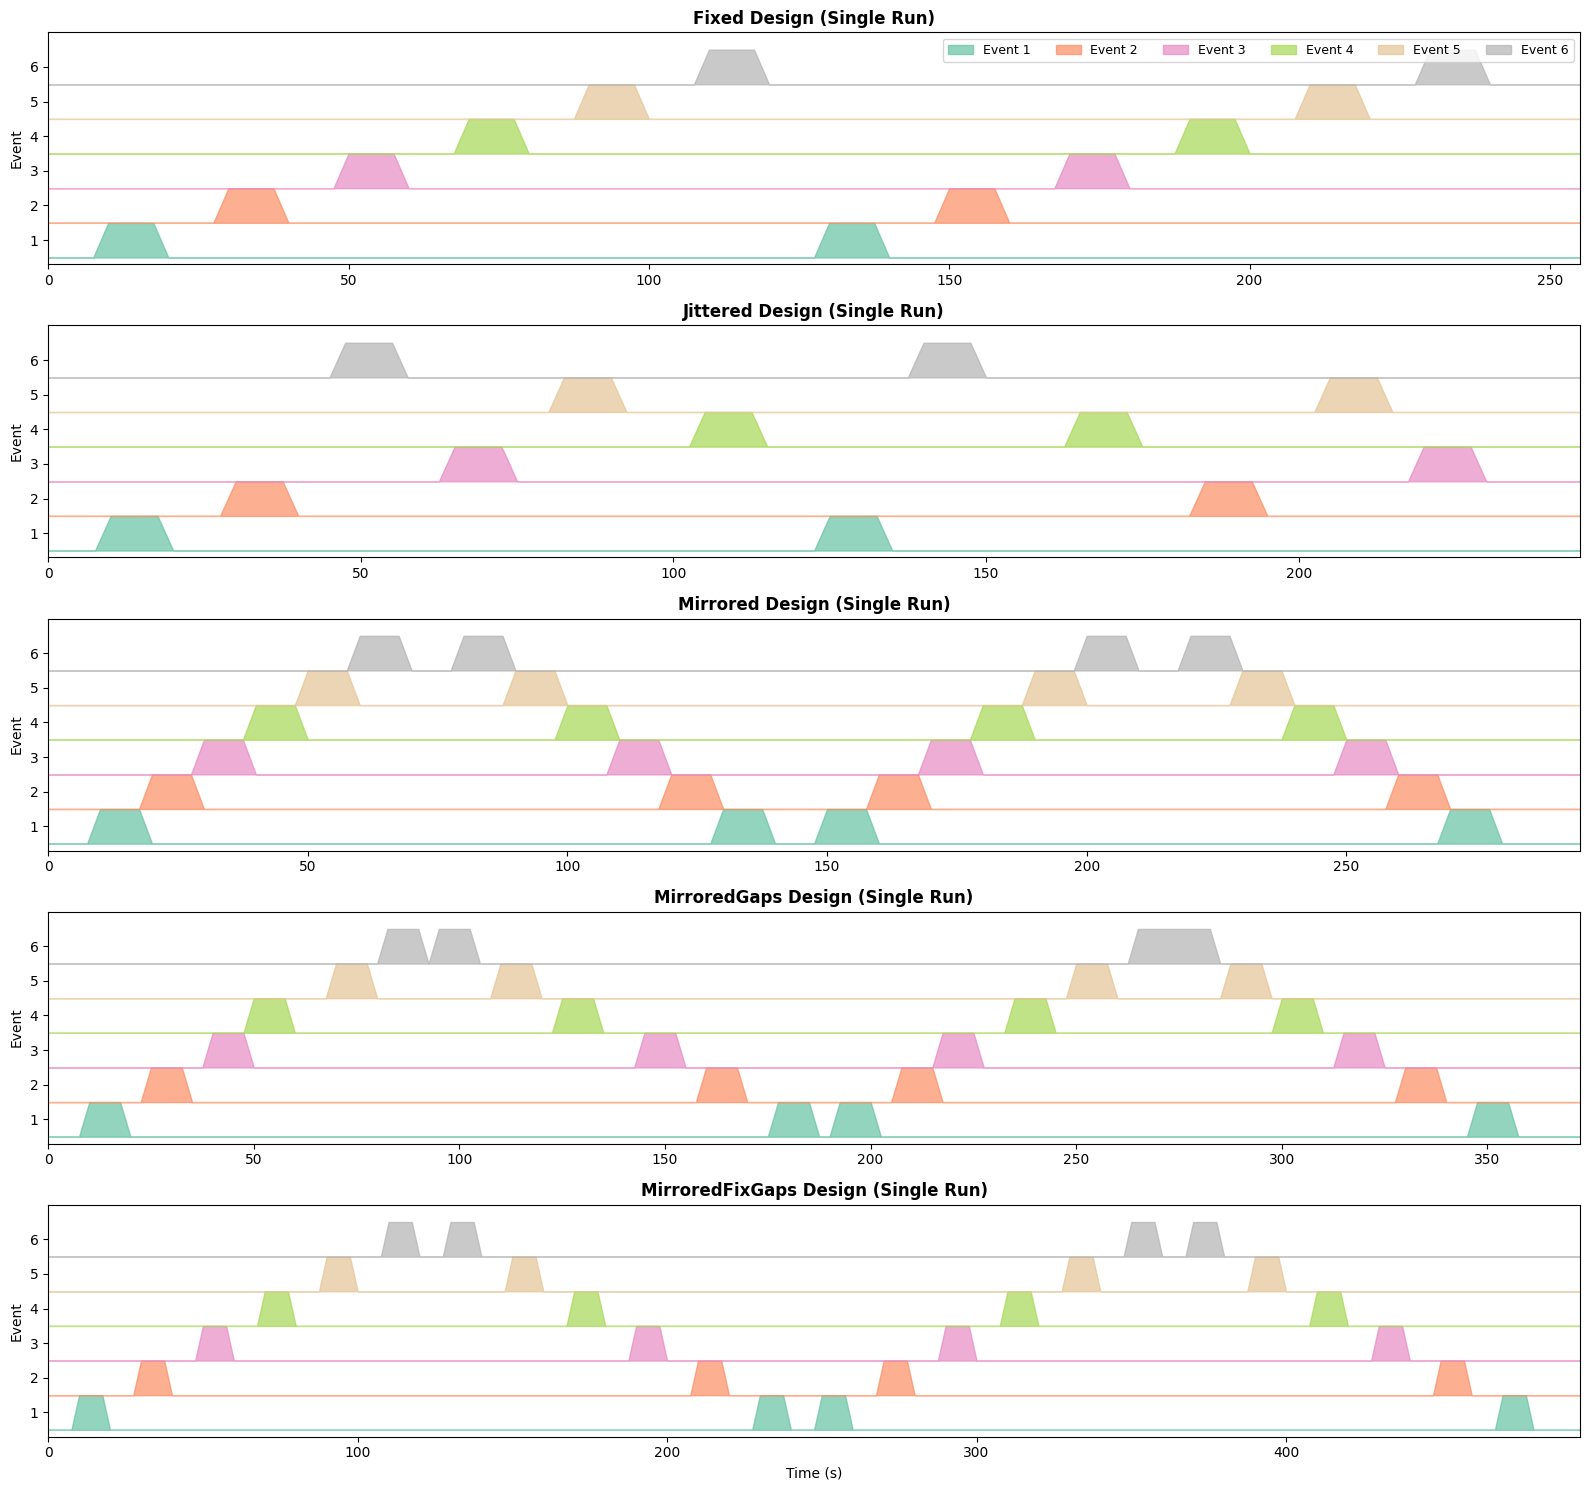

In [161]:
# Visualize designs (single run)
n_designs = len(designs)
fig, axes = plt.subplots(n_designs, 1, figsize=(16, 3*n_designs))
if n_designs == 1:
    axes = [axes]

colors = plt.cm.Set2(np.linspace(0, 1, N_EVENTS))

for ax, (name, d) in zip(axes, designs.items()):
    onsets = d['onsets_single']
    time_axis = np.arange(onsets.shape[0]) * TR
    
    for event_id in range(N_EVENTS):
        signal = onsets[:, event_id].cpu().numpy()
        ax.fill_between(time_axis, event_id, event_id + signal,
                       alpha=0.7, color=colors[event_id], 
                       label=f'Event {event_id+1}' if ax == axes[0] else None)
    
    ax.set_xlim(0, time_axis[-1])
    ax.set_ylim(-0.2, N_EVENTS + 0.5)
    ax.set_ylabel('Event')
    ax.set_title(f'{name} Design (Single Run)', fontsize=12, fontweight='bold')
    ax.set_yticks(np.arange(N_EVENTS) + 0.5)
    ax.set_yticklabels([f'{i+1}' for i in range(N_EVENTS)])

axes[-1].set_xlabel('Time (s)')
axes[0].legend(loc='upper right', ncol=N_EVENTS, fontsize=9)
plt.tight_layout()
plt.show()

## HRF Setup

Using HRF #12 for simulation, canonical for recovery


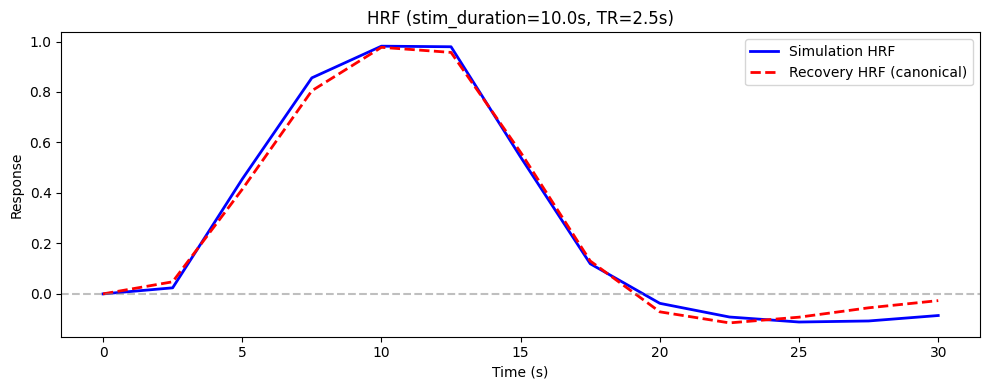

In [162]:
# Get HRFs
hrf_canonical = ffs.get_canonical_hrf(stim_duration=STIM_DURATION, tr=TR, device=device)
hrf_library = ffs.get_hrf_library(mode='library', stim_duration=STIM_DURATION, tr=TR, device=device)

if USE_DIFFERENT_HRF:
    hrf_simulation = hrf_library[SIMULATION_HRF_INDEX]
    print(f"Using HRF #{SIMULATION_HRF_INDEX} for simulation, canonical for recovery")
else:
    hrf_simulation = hrf_canonical
    print("Using canonical HRF for both simulation and recovery")

hrf_recovery = hrf_canonical

# Plot HRFs
fig, ax = plt.subplots(figsize=(10, 4))
hrf_time = np.arange(len(hrf_canonical)) * TR

ax.plot(hrf_time, hrf_simulation.cpu().numpy(), 'b-', linewidth=2, label='Simulation HRF')
if USE_DIFFERENT_HRF:
    ax.plot(hrf_time, hrf_recovery.cpu().numpy(), 'r--', linewidth=2, label='Recovery HRF (canonical)')

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Response')
ax.set_title(f'HRF (stim_duration={STIM_DURATION}s, TR={TR}s)')
ax.legend()
plt.tight_layout()
plt.show()

## Convolve Designs with HRF

In [163]:
# Convolve with both HRFs (single run designs)
for name, d in designs.items():
    onsets = d['onsets_single']
    n_tps = onsets.shape[0]
    
    # For simulation (ground truth signal)
    d['design_sim_single'] = ffs.convolve_hrf(onsets, hrf_simulation, n_timepoints=n_tps, device=device)
    
    # For recovery (GLM fitting)
    d['design_glm_single'] = ffs.convolve_hrf(onsets, hrf_recovery, n_timepoints=n_tps, device=device)
    
print("Convolved all single-run designs.")

Convolved all single-run designs.


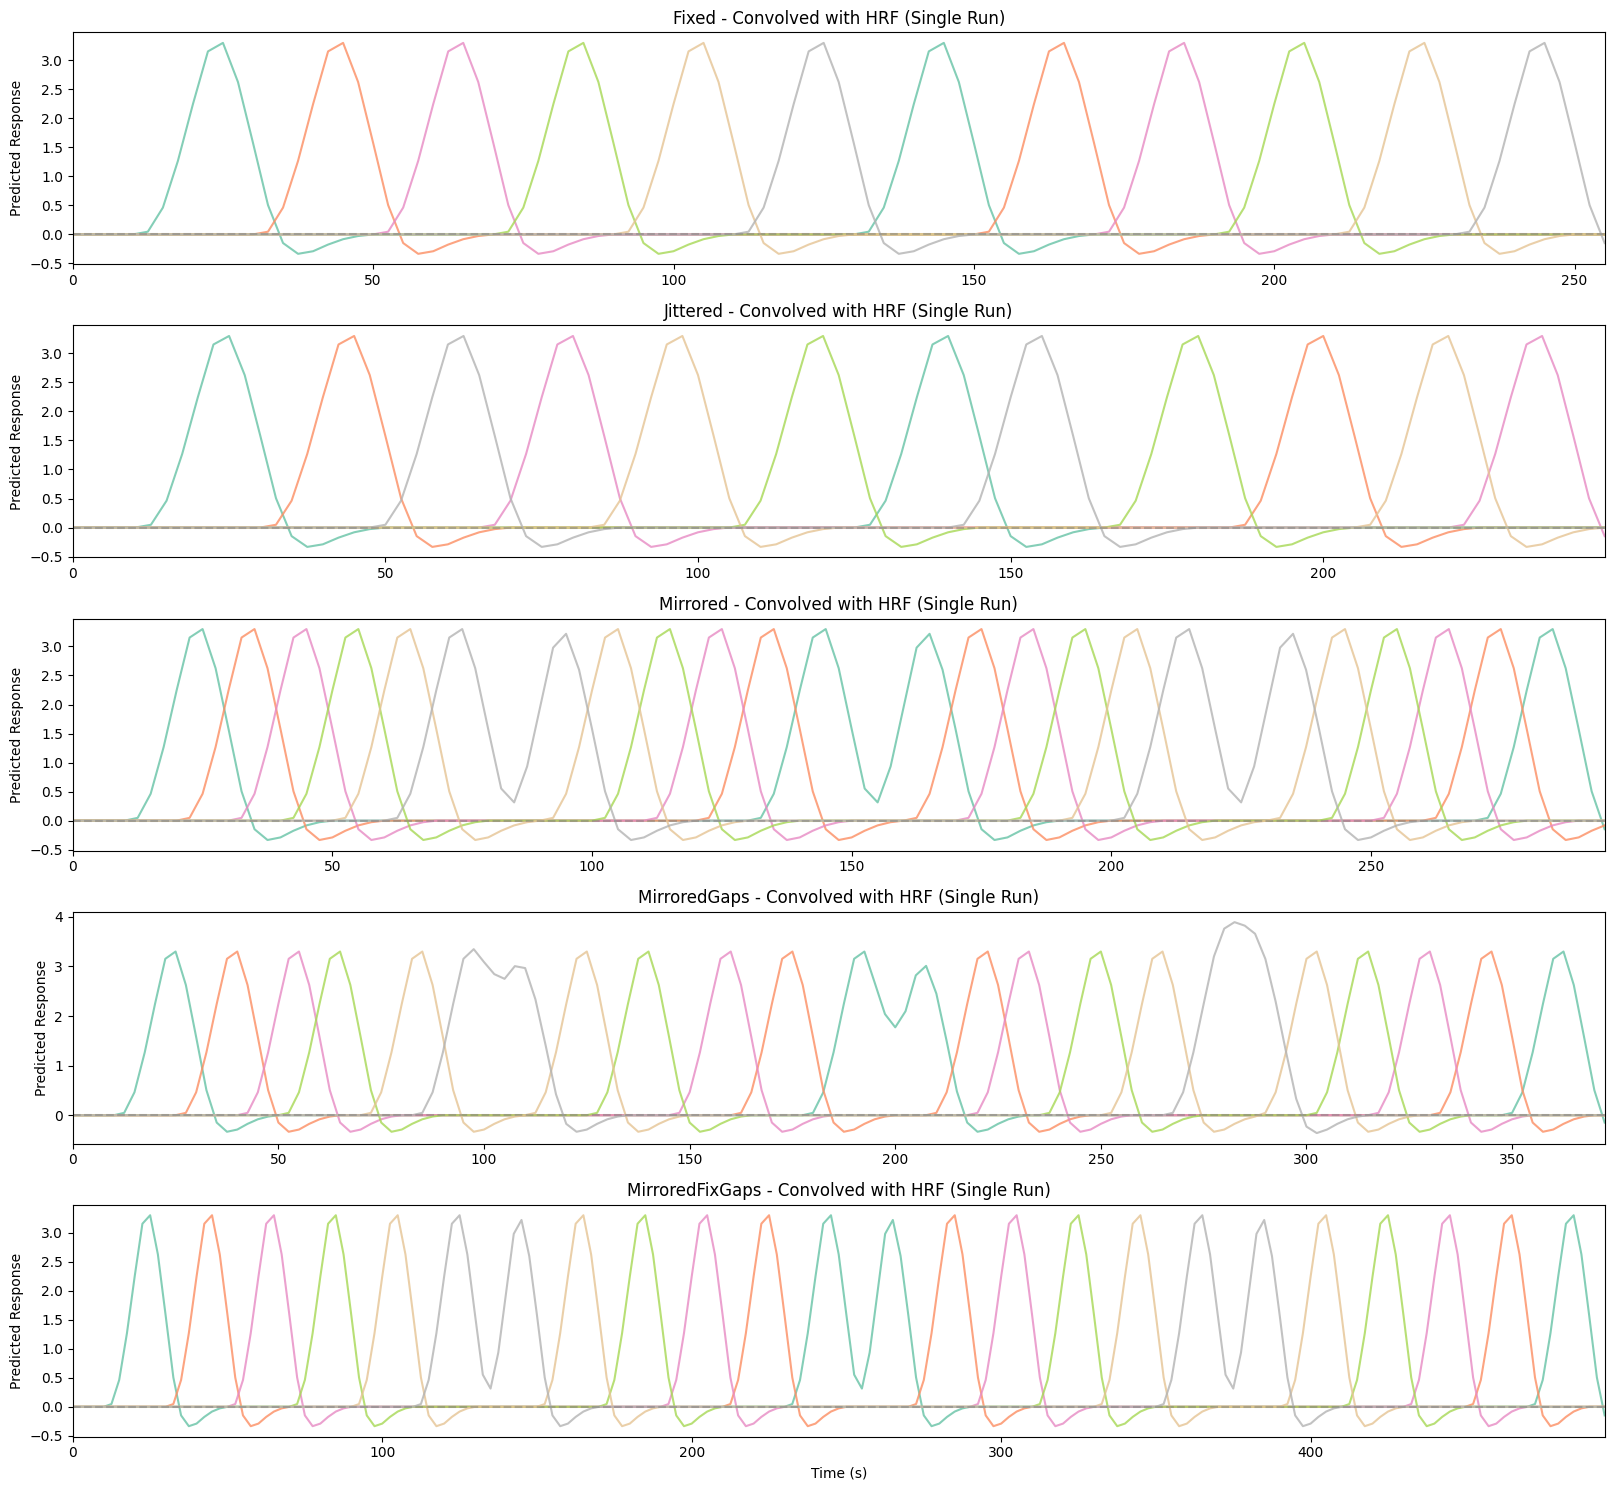

In [164]:
# Visualize convolved designs (single run)
fig, axes = plt.subplots(n_designs, 1, figsize=(16, 3*n_designs))
if n_designs == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, designs.items()):
    design = d['design_glm_single']
    time_axis = np.arange(design.shape[0]) * TR
    design_np = design.cpu().numpy()
    
    for event_id in range(N_EVENTS):
        ax.plot(time_axis, design_np[:, event_id], color=colors[event_id],
               linewidth=1.5, alpha=0.8)
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_xlim(0, time_axis[-1])
    ax.set_ylabel('Predicted Response')
    ax.set_title(f'{name} - Convolved with HRF (Single Run)')

axes[-1].set_xlabel('Time (s)')
plt.tight_layout()
plt.show()

## Design Matrix Correlation Analysis

Lower correlation between regressors → better beta estimation (less multicollinearity).

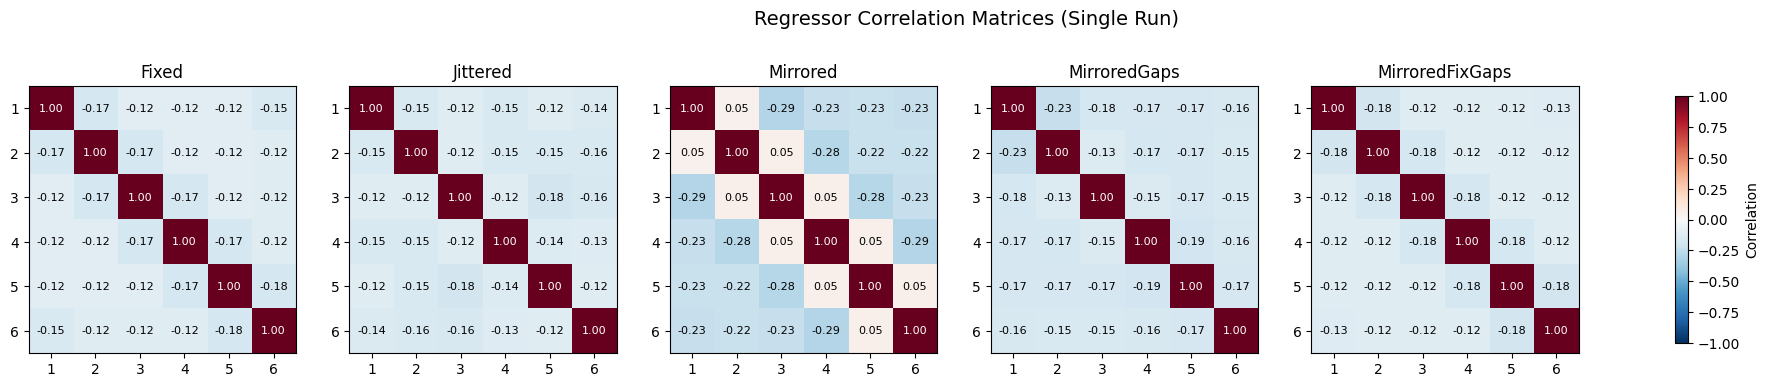


Mean |off-diagonal correlation|:
  Fixed       : 0.1383
  Jittered    : 0.1416
  MirroredFixGaps: 0.1423
  MirroredGaps: 0.1676
  Mirrored    : 0.1835


In [165]:
fig, axes = plt.subplots(1, n_designs, figsize=(5*n_designs, 4))
if n_designs == 1:
    axes = [axes]

design_correlations = {}

for ax, (name, d) in zip(axes, designs.items()):
    design_np = d['design_glm_single'].cpu().numpy()
    corr = np.corrcoef(design_np.T)
    
    im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(f'{name}')
    ax.set_xticks(range(N_EVENTS))
    ax.set_yticks(range(N_EVENTS))
    ax.set_xticklabels([f'{i+1}' for i in range(N_EVENTS)])
    ax.set_yticklabels([f'{i+1}' for i in range(N_EVENTS)])
    
    for i in range(N_EVENTS):
        for j in range(N_EVENTS):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center',
                   fontsize=8, color='white' if abs(corr[i,j]) > 0.5 else 'black')
    
    off_diag = corr[np.triu_indices(N_EVENTS, k=1)]
    design_correlations[name] = np.abs(off_diag).mean()

plt.colorbar(im, ax=axes, shrink=0.8, label='Correlation')
plt.suptitle('Regressor Correlation Matrices (Single Run)', fontsize=14, y=1.02)
# plt.tight_layout()
plt.show()

print("\nMean |off-diagonal correlation|:")
for name, corr in sorted(design_correlations.items(), key=lambda x: x[1]):
    print(f"  {name:12s}: {corr:.4f}")

## Build Full GLM Design Matrices (with Polynomials)

In [166]:
def build_polynomial_regressors(n_timepoints: int, poly_order: int) -> torch.Tensor:
    """
    Build polynomial regressors for drift modeling.
    
    Args:
        n_timepoints: number of TRs
        poly_order: maximum polynomial order (0=mean, 1=linear, 2=quadratic)
    
    Returns:
        poly_regs: (n_timepoints, poly_order+1) tensor
    """
    t = torch.linspace(-1, 1, n_timepoints, device=device)
    poly_regs = []
    
    for order in range(poly_order + 1):
        reg = t ** order
        # Normalize (except constant)
        if order > 0:
            reg = reg / reg.abs().max()
        poly_regs.append(reg)
    
    return torch.stack(poly_regs, dim=1)


def build_multirun_design(task_design_single: torch.Tensor, 
                          n_runs: int, 
                          poly_order: int) -> Tuple[torch.Tensor, List[int]]:
    """
    Build multi-run design matrix with block-diagonal polynomials.
    
    Task regressors are concatenated (same across runs).
    Polynomial regressors are block-diagonal (separate per run).
    
    Args:
        task_design_single: (n_tps_per_run, n_events) task design for one run
        n_runs: number of runs
        poly_order: polynomial order per run
    
    Returns:
        design_full: (n_tps_total, n_events + n_runs*(poly_order+1)) full design
        run_starts: list of starting indices for each run
    """
    n_tps_per_run = task_design_single.shape[0]
    n_events = task_design_single.shape[1]
    n_tps_total = n_tps_per_run * n_runs
    
    # Concatenate task regressors (identical across runs)
    task_design_concat = task_design_single.repeat(n_runs, 1)  # (n_tps_total, n_events)
    
    # Build block-diagonal polynomial matrix
    poly_blocks = []
    for run in range(n_runs):
        poly_block = build_polynomial_regressors(n_tps_per_run, poly_order)
        poly_blocks.append(poly_block)
    
    # Stack as block-diagonal
    poly_design = torch.block_diag(*poly_blocks)  # (n_tps_total, n_runs*(poly_order+1))
    
    # Combine: [task regressors | polynomial regressors]
    design_full = torch.cat([task_design_concat, poly_design], dim=1)
    
    # Run start indices
    run_starts = [i * n_tps_per_run for i in range(n_runs)]
    
    return design_full, run_starts


# Build multi-run design matrices for GLM
print("Building multi-run design matrices...\n")

for name, d in designs.items():
    d['design_full'], d['run_starts'] = build_multirun_design(
        d['design_glm_single'], N_RUNS, POLY_ORDER
    )
    
    # Also build simulation design (for generating ground truth signal)
    d['design_sim_concat'] = d['design_sim_single'].repeat(N_RUNS, 1)
    
    n_task = N_EVENTS
    n_poly = N_RUNS * (POLY_ORDER + 1)
    print(f"{name}: {d['design_full'].shape} ({n_task} task + {n_poly} poly [{POLY_ORDER+1}/run × {N_RUNS} runs])")

print(f"\nRun starts: {d['run_starts']}")

Building multi-run design matrices...

Fixed: torch.Size([721, 34]) (6 task + 28 poly [4/run × 7 runs])
Jittered: torch.Size([693, 34]) (6 task + 28 poly [4/run × 7 runs])
Mirrored: torch.Size([833, 34]) (6 task + 28 poly [4/run × 7 runs])
MirroredGaps: torch.Size([1050, 34]) (6 task + 28 poly [4/run × 7 runs])
MirroredFixGaps: torch.Size([1393, 34]) (6 task + 28 poly [4/run × 7 runs])

Run starts: [0, 199, 398, 597, 796, 995, 1194]


## Multi-Run Design Matrix Visualization

The design matrix has two parts:
1. **Task regressors** (left): HRF-convolved stimulus predictors, identical across runs
2. **Polynomial regressors** (right): Block-diagonal structure with separate polynomials per run

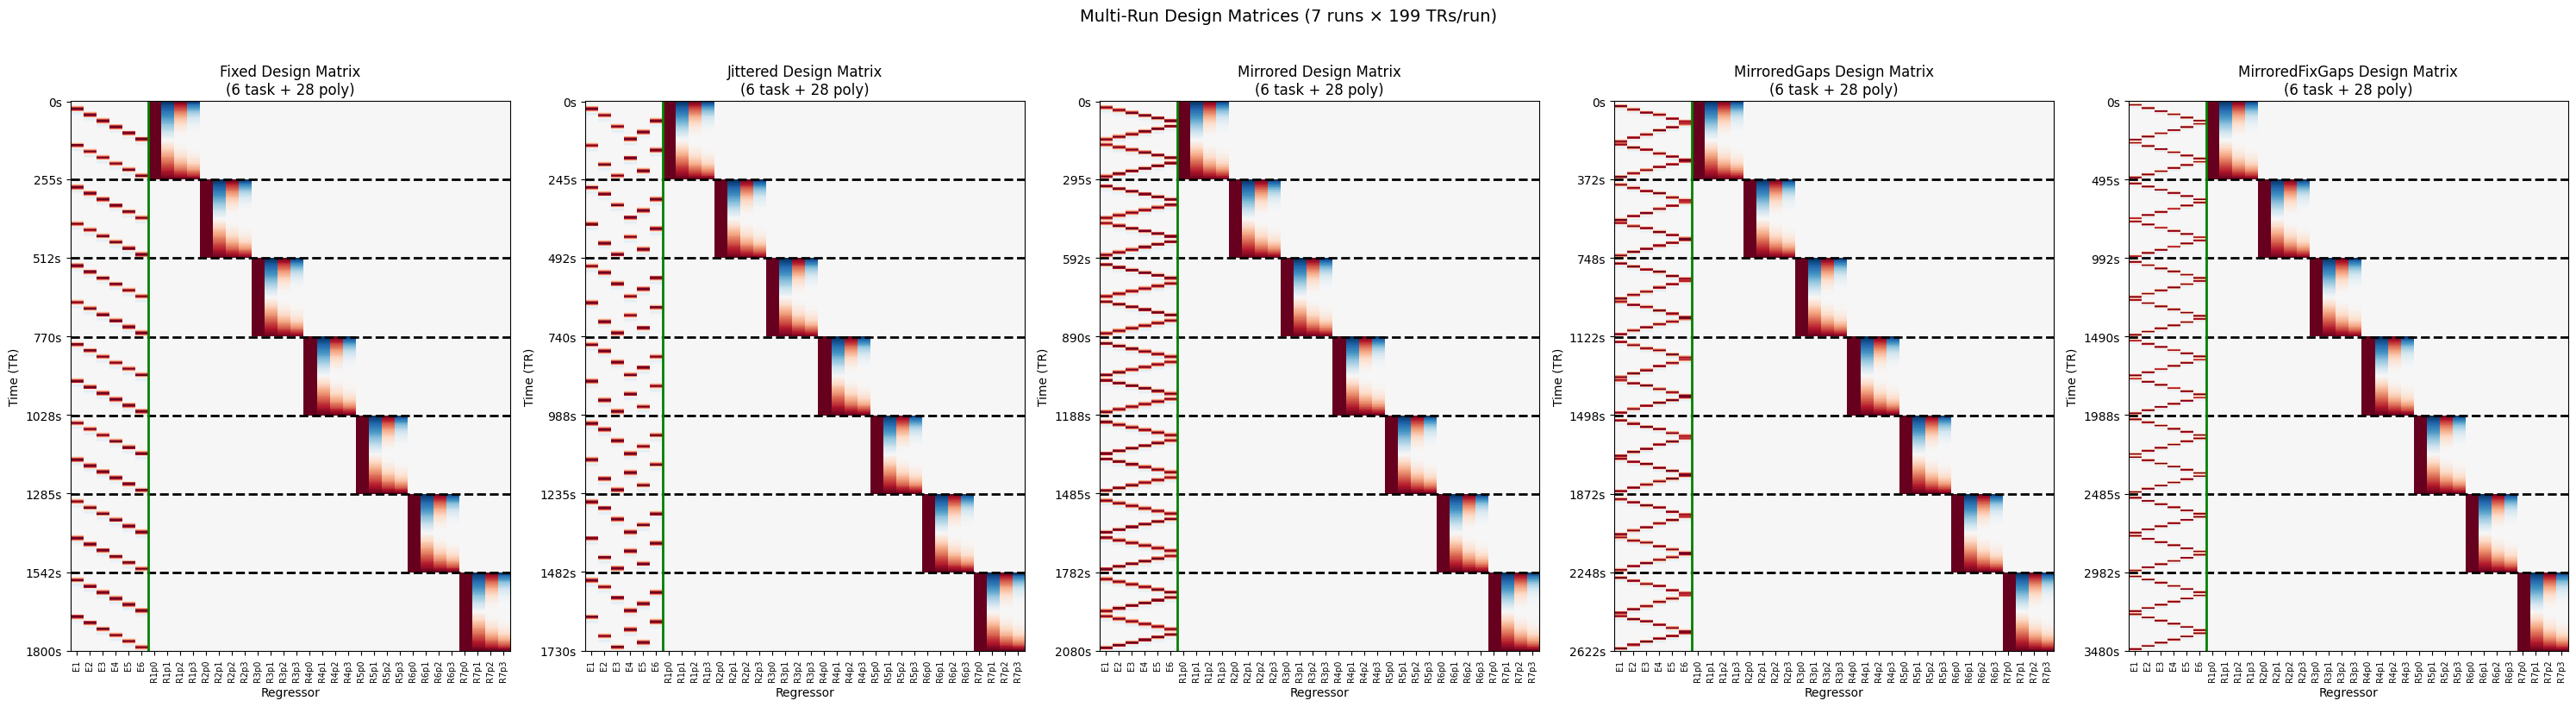

Green line: separates task regressors (left) from polynomial regressors (right)
Black dashed lines: run boundaries
Block-diagonal structure in polynomials ensures each run has independent drift modeling


In [167]:
# Visualize multi-run design matrices (imagesc style)
fig, axes = plt.subplots(1, n_designs, figsize=(6*n_designs, 8))
if n_designs == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, designs.items()):
    design_np = d['design_full'].cpu().numpy()
    n_tps, n_cols = design_np.shape
    n_task = N_EVENTS
    n_poly = n_cols - n_task
    
    # Normalize columns for visualization (so all have similar scale)
    design_viz = design_np.copy()
    for col in range(n_cols):
        col_max = np.abs(design_viz[:, col]).max()
        if col_max > 0:
            design_viz[:, col] = design_viz[:, col] / col_max
    
    # Use diverging colormap centered at 0
    vmax = np.abs(design_viz).max()
    im = ax.imshow(design_viz, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                   interpolation='nearest')
    
    # Mark run boundaries
    for run_start in d['run_starts'][1:]:
        ax.axhline(run_start - 0.5, color='black', linewidth=2, linestyle='--')
    
    # Mark task/poly boundary
    ax.axvline(N_EVENTS - 0.5, color='green', linewidth=2, linestyle='-')
    
    # Labels
    ax.set_xlabel('Regressor')
    ax.set_ylabel('Time (TR)')
    ax.set_title(f'{name} Design Matrix\n({n_task} task + {n_poly} poly)')
    
    # X-axis labels
    xlabels = [f'E{i+1}' for i in range(N_EVENTS)]
    for run in range(N_RUNS):
        for p in range(POLY_ORDER + 1):
            xlabels.append(f'R{run+1}p{p}')
    
    ax.set_xticks(range(n_cols))
    ax.set_xticklabels(xlabels, rotation=90, fontsize=7)
    
    # Y-axis: show time in seconds for a few ticks
    n_yticks = 8
    ytick_idx = np.linspace(0, n_tps-1, n_yticks).astype(int)
    ax.set_yticks(ytick_idx)
    ax.set_yticklabels([f'{idx*TR:.0f}s' for idx in ytick_idx])

# plt.colorbar(im, ax=axes, shrink=0.6, label='Normalized amplitude')
plt.suptitle(f'Multi-Run Design Matrices ({N_RUNS} runs × {d["n_tps_per_run"]} TRs/run)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Green line: separates task regressors (left) from polynomial regressors (right)")
print("Black dashed lines: run boundaries")
print("Block-diagonal structure in polynomials ensures each run has independent drift modeling")

## Simulate fMRI Data

Using 1/f colored noise (FFT-based) with polynomial drift.

In [168]:
def simulate_fmri_run(design_sim: torch.Tensor, 
                      betas: List[float],
                      noise_level: float,
                      pink_exp: float,
                      n_voxels: int,
                      baseline: float = 100.0) -> torch.Tensor:
    """
    Simulate one run of fMRI data with colored noise.
    
    Args:
        design_sim: (n_timepoints, n_events) HRF-convolved design
        betas: true betas per event
        noise_level: noise amplitude relative to signal std
        pink_exp: 1/f^α exponent (1=pink, 0=white, 2=brown)
        n_voxels: number of voxels
        baseline: mean signal level
    
    Returns:
        data: (n_voxels, n_timepoints) tensor
    """
    n_tps = design_sim.shape[0]
    betas_t = torch.tensor(betas, dtype=torch.float32, device=device)
    
    # True signal
    signal = design_sim @ betas_t  # (n_tps,)
    signal = signal.unsqueeze(0).expand(n_voxels, -1)  # (n_voxels, n_tps)
    

    # Generate 1/f colored noise using FFT
    duration_s = n_tps * TR
    noise = ffs.generate_fmri_noise(
        tr=TR,
        duration_s=duration_s,
        matrix_size=(1, n_voxels),  # Generate for all voxels
        pink_exp=pink_exp,
        resp_strength=0.0,  # No physiological noise for simplicity
        cardiac_strength=0.0,
        normalize=True,
        device=device
    )  # (n_tps, 1, n_voxels)
    
    noise = noise.squeeze(1).T  # (n_voxels, n_tps)
    
    # Scale noise relative to signal
    signal_std = signal.std()
    if signal_std > 0:
        noise = noise * noise_level * signal_std
    
    # Combine
    data = baseline + signal + noise
    return data


def simulate_multirun_data(design_sim_single: torch.Tensor,
                           betas: List[float],
                           n_runs: int,
                           noise_level: float,
                           pink_exp: float,
                           n_voxels: int,
                           baseline: float = 100.0) -> Tuple[torch.Tensor, List[torch.Tensor]]:
    """
    Simulate multi-run fMRI data.
    
    Each run gets independent noise (as in real fMRI).
    
    Returns:
        data_concat: (n_voxels, n_tps_total) concatenated data
        data_runs: list of (n_voxels, n_tps_per_run) per-run data
    """
    data_runs = []
    
    for run in range(n_runs):
        run_data = simulate_fmri_run(
            design_sim_single, betas, noise_level, pink_exp, n_voxels, baseline
        )
        data_runs.append(run_data)
    
    # Concatenate along time dimension
    data_concat = torch.cat(data_runs, dim=1)  # (n_voxels, n_tps_total)
    
    return data_concat, data_runs


# Simulate multi-run data for each design
print("Simulating multi-run data...\n")

for name, d in designs.items():
    d['data'], d['data_runs'] = simulate_multirun_data(
        d['design_sim_single'], TRUE_BETAS, N_RUNS, NOISE_LEVEL, PINK_EXPONENT, N_VOXELS
    )
    n_tps_total = d['data'].shape[1]
    n_tps_per_run = d['n_tps_per_run']
    print(f"{name}: {N_RUNS} runs × {n_tps_per_run} TRs = {n_tps_total} total TRs")
    print(f"  Data shape: {d['data'].shape}, mean={d['data'].mean():.1f}, std={d['data'].std():.2f}")

Simulating multi-run data...

Fixed: 7 runs × 103 TRs = 721 total TRs
  Data shape: torch.Size([1000, 721]), mean=103.8, std=8.79
Jittered: 7 runs × 99 TRs = 693 total TRs
  Data shape: torch.Size([1000, 693]), mean=103.9, std=9.25
Mirrored: 7 runs × 119 TRs = 833 total TRs
  Data shape: torch.Size([1000, 833]), mean=106.4, std=11.33
MirroredGaps: 7 runs × 150 TRs = 1050 total TRs
  Data shape: torch.Size([1000, 1050]), mean=105.1, std=10.23
MirroredFixGaps: 7 runs × 199 TRs = 1393 total TRs
  Data shape: torch.Size([1000, 1393]), mean=103.8, std=8.56


In [169]:
# Measure actual TSNR from simulated data
print("Measured TSNR from Simulated Data")
print("=" * 70)

for name, d in designs.items():
    data = d['data'].cpu().numpy()  # (n_voxels, n_tps)
    
    # TSNR per voxel: mean / std across time
    voxel_means = data.mean(axis=1)
    voxel_stds = data.std(axis=1)
    tsnr_per_voxel = voxel_means / (voxel_stds + 1e-10)
    
    print(f"{name}:")
    print(f"  Mean TSNR: {tsnr_per_voxel.mean():.1f} ± {tsnr_per_voxel.std():.1f}")
    print(f"  Range: [{tsnr_per_voxel.min():.1f}, {tsnr_per_voxel.max():.1f}]")

print()
print("Note: TSNR includes both baseline and BOLD signal variance.")
print("Real fMRI: 50-100 for typical data, 30-60 for high-res 7T.")

Measured TSNR from Simulated Data
Fixed:
  Mean TSNR: 11.8 ± 0.2
  Range: [11.2, 12.5]
Jittered:
  Mean TSNR: 11.2 ± 0.2
  Range: [10.6, 12.0]
Mirrored:
  Mean TSNR: 9.4 ± 0.2
  Range: [8.9, 9.9]
MirroredGaps:
  Mean TSNR: 10.3 ± 0.2
  Range: [9.7, 10.9]
MirroredFixGaps:
  Mean TSNR: 12.1 ± 0.2
  Range: [11.6, 12.8]

Note: TSNR includes both baseline and BOLD signal variance.
Real fMRI: 50-100 for typical data, 30-60 for high-res 7T.


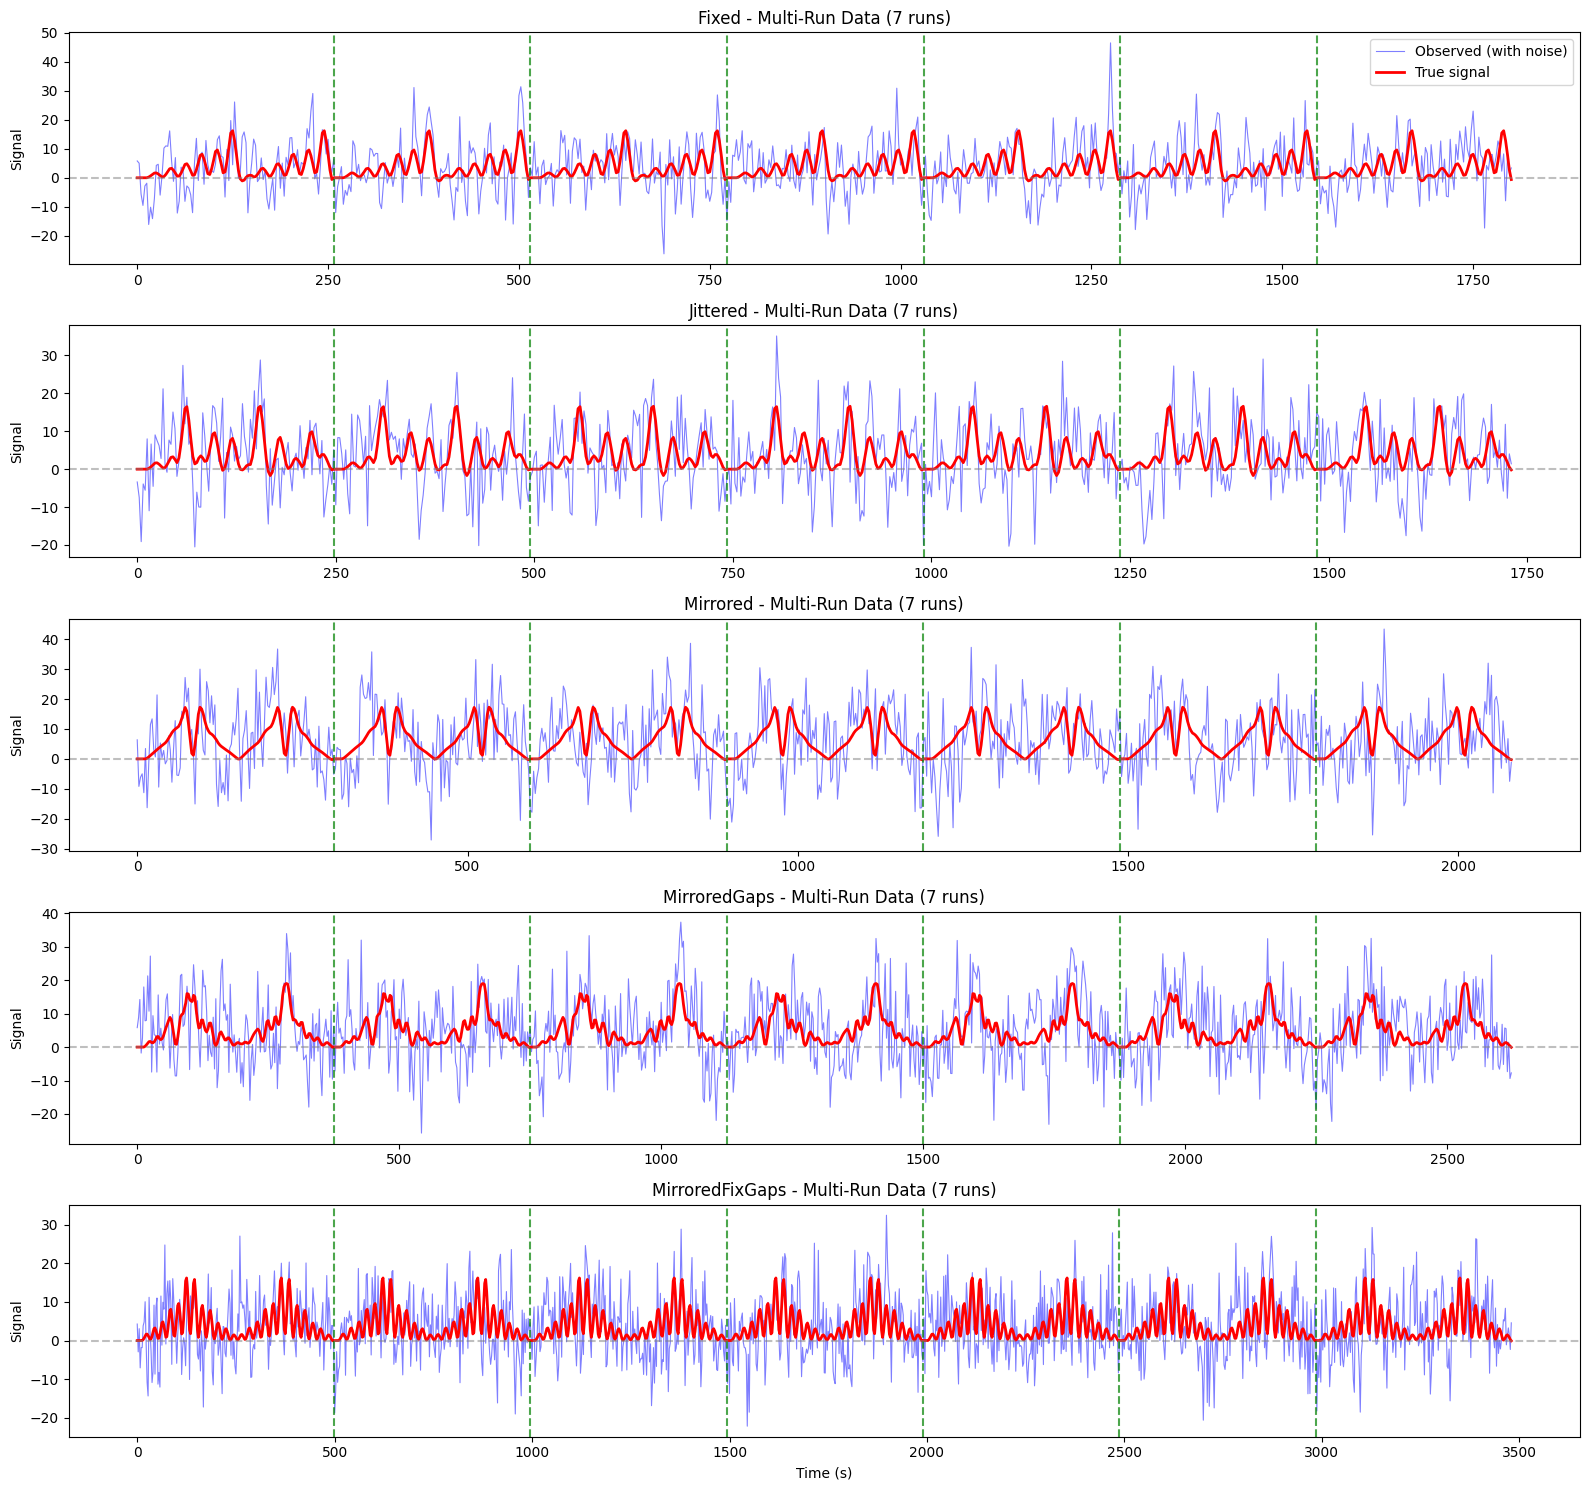

Green dashed lines mark run boundaries


In [170]:
# Visualize simulated timecourse (one voxel, all runs)
voxel_idx = 0
baseline = 100.0

fig, axes = plt.subplots(n_designs, 1, figsize=(16, 3*n_designs))
if n_designs == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, designs.items()):
    data = d['data']
    n_tps_total = data.shape[1]
    time_axis = np.arange(n_tps_total) * TR
    
    # True signal (concatenated across runs)
    betas_t = torch.tensor(TRUE_BETAS, device=device)
    true_signal = (d['design_sim_concat'] @ betas_t).cpu().numpy()
    
    ax.plot(time_axis, data[voxel_idx].cpu().numpy() - baseline, 'b-', alpha=0.5,
           linewidth=0.8, label='Observed (with noise)')
    ax.plot(time_axis, true_signal, 'r-', linewidth=2, label='True signal')
    
    # Mark run boundaries
    for run_start in d['run_starts'][1:]:
        ax.axvline(run_start * TR, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
    
    ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax.set_ylabel('Signal')
    ax.set_title(f'{name} - Multi-Run Data ({N_RUNS} runs)')

axes[-1].set_xlabel('Time (s)')
axes[0].legend(loc='upper right')
plt.tight_layout()
plt.show()

print("Green dashed lines mark run boundaries")

## Signal Decomposition: Clean Signal vs Noise

Let's visualize the components that make up our simulated data.

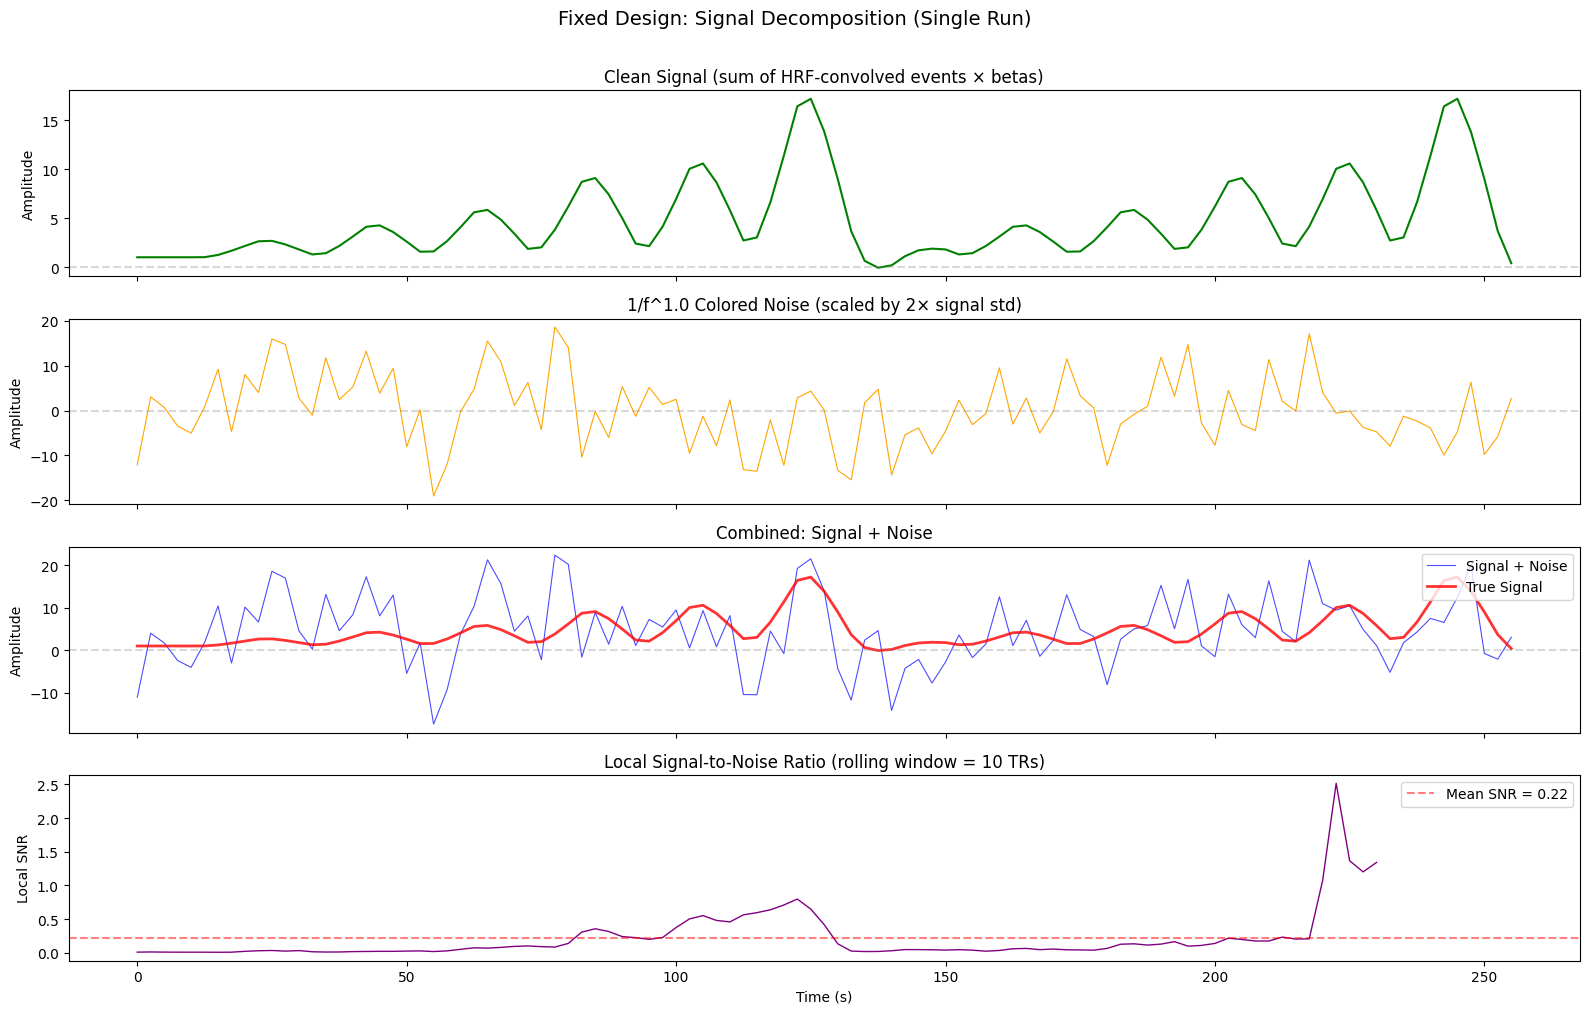


Signal Statistics:
  Clean signal std: 3.9455
  Noise std: 7.8526
  Global SNR: 0.25


In [171]:
# Signal decomposition for one design (single run)
design_name = list(designs.keys())[0]  # Use first design for demonstration
d = designs[design_name]

# Get components (single run)
betas_t = torch.tensor(TRUE_BETAS, device=device)
n_tps = d['n_tps_per_run']
duration_s = n_tps * TR

# Clean signal (single run)
clean_signal = (d['design_sim_single'] @ betas_t).cpu().numpy() +1

# Generate a fresh noise sample for visualization
noise_sample = ffs.generate_fmri_noise(
    tr=TR, duration_s=duration_s, matrix_size=(1, 1),
    pink_exp=PINK_EXPONENT, resp_strength=0.0, cardiac_strength=0.0,
    normalize=True, device=device
).cpu().numpy().flatten()

# Scale noise as we do in simulation
signal_std = clean_signal.std()
scaled_noise = noise_sample * NOISE_LEVEL * signal_std

# Combined
combined = clean_signal + scaled_noise

time_axis = np.arange(n_tps) * TR

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)

# Clean signal
axes[0].plot(time_axis, clean_signal, 'g-', linewidth=1.5)
axes[0].set_ylabel('Amplitude')
axes[0].set_title(f'Clean Signal (sum of HRF-convolved events × betas)')
axes[0].axhline(0, color='gray', linestyle='--', alpha=0.3)

# Noise
axes[1].plot(time_axis, scaled_noise, 'orange', linewidth=0.8)
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'1/f^{PINK_EXPONENT} Colored Noise (scaled by {NOISE_LEVEL}× signal std)')
axes[1].axhline(0, color='gray', linestyle='--', alpha=0.3)

# Combined (without baseline)
axes[2].plot(time_axis, combined, 'b-', linewidth=0.8, alpha=0.7, label='Signal + Noise')
axes[2].plot(time_axis, clean_signal, 'r-', linewidth=2, alpha=0.8, label='True Signal')
axes[2].set_ylabel('Amplitude')
axes[2].set_title('Combined: Signal + Noise')
axes[2].legend(loc='upper right')
axes[2].axhline(0, color='gray', linestyle='--', alpha=0.3)

# SNR over time (local SNR)
window = 10  # TRs
snr_local = []
for i in range(n_tps - window):
    sig_power = np.var(clean_signal[i:i+window])
    noise_power = np.var(scaled_noise[i:i+window])
    snr_local.append(sig_power / (noise_power + 1e-10))

axes[3].plot(time_axis[:len(snr_local)], snr_local, 'purple', linewidth=1)
axes[3].set_ylabel('Local SNR')
axes[3].set_xlabel('Time (s)')
axes[3].set_title(f'Local Signal-to-Noise Ratio (rolling window = {window} TRs)')
axes[3].axhline(np.mean(snr_local), color='red', linestyle='--', alpha=0.5, 
               label=f'Mean SNR = {np.mean(snr_local):.2f}')
axes[3].legend()

plt.suptitle(f'{design_name} Design: Signal Decomposition (Single Run)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nSignal Statistics:")
print(f"  Clean signal std: {clean_signal.std():.4f}")
print(f"  Noise std: {scaled_noise.std():.4f}")
print(f"  Global SNR: {clean_signal.std()**2 / scaled_noise.std()**2:.2f}")

## Noise Power Spectrum

Visualize the frequency content of our colored noise. 1/f^α noise has more power at low frequencies.

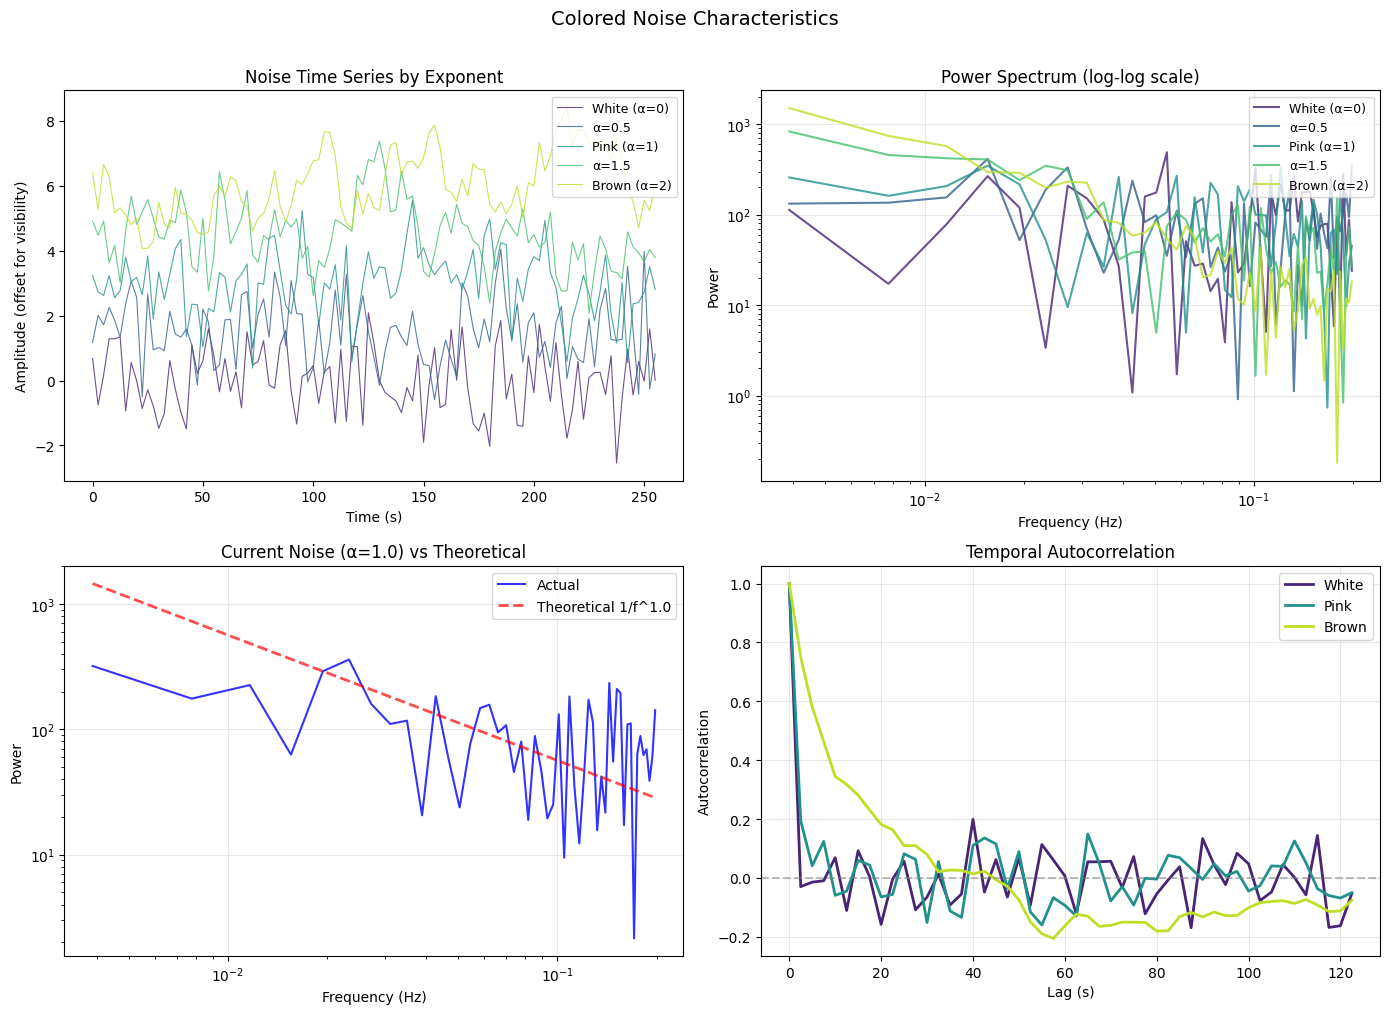


Current noise settings: 1/f^1.0
  α=0 (white): No temporal correlation, flat spectrum
  α=1 (pink): Equal power per octave, typical fMRI noise
  α=2 (brown): Strong low-frequency drift


In [172]:
# Compare power spectra of different noise types
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Generate noise with different exponents
noise_exponents = [0.0, 0.5, 1.0, 1.5, 2.0]
noise_labels = ['White (α=0)', 'α=0.5', 'Pink (α=1)', 'α=1.5', 'Brown (α=2)']
noise_colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(noise_exponents)))

# Use the single-run duration
n_tps = list(designs.values())[0]['n_tps_per_run']
duration_s = n_tps * TR

# Top left: Time domain comparison
ax = axes[0, 0]
for exp, label, color in zip(noise_exponents, noise_labels, noise_colors):
    noise = ffs.generate_fmri_noise(
        tr=TR, duration_s=duration_s, matrix_size=(1, 1),
        pink_exp=exp, resp_strength=0.0, cardiac_strength=0.0,
        normalize=True, device=device
    ).cpu().numpy().flatten()
    ax.plot(np.arange(n_tps) * TR, noise + exp * 3, color=color, 
           linewidth=0.8, alpha=0.8, label=label)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude (offset for visibility)')
ax.set_title('Noise Time Series by Exponent')
ax.legend(loc='upper right', fontsize=9)

# Top right: Power spectrum comparison
ax = axes[0, 1]
for exp, label, color in zip(noise_exponents, noise_labels, noise_colors):
    noise = ffs.generate_fmri_noise(
        tr=TR, duration_s=duration_s, matrix_size=(1, 1),
        pink_exp=exp, resp_strength=0.0, cardiac_strength=0.0,
        normalize=True, device=device
    ).cpu().numpy().flatten()
    
    # Compute power spectrum
    fft = np.fft.rfft(noise)
    power = np.abs(fft) ** 2
    freqs = np.fft.rfftfreq(len(noise), d=TR)
    
    # Smooth for visualization
    ax.loglog(freqs[1:], power[1:], color=color, linewidth=1.5, alpha=0.8, label=label)

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power')
ax.set_title('Power Spectrum (log-log scale)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)

# Bottom left: Current noise power spectrum with theoretical line
ax = axes[1, 0]
noise_current = ffs.generate_fmri_noise(
    tr=TR, duration_s=duration_s, matrix_size=(1, 1),
    pink_exp=PINK_EXPONENT, resp_strength=0.0, cardiac_strength=0.0,
    normalize=True, device=device
).cpu().numpy().flatten()

fft = np.fft.rfft(noise_current)
power = np.abs(fft) ** 2
freqs = np.fft.rfftfreq(len(noise_current), d=TR)

ax.loglog(freqs[1:], power[1:], 'b-', linewidth=1.5, alpha=0.8, label='Actual')

# Theoretical 1/f^α line
f_theory = freqs[1:]
p_theory = 1 / (f_theory ** PINK_EXPONENT)
p_theory = p_theory * (power[5] / p_theory[4])  # Scale to match
ax.loglog(f_theory, p_theory, 'r--', linewidth=2, alpha=0.7, label=f'Theoretical 1/f^{PINK_EXPONENT}')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power')
ax.set_title(f'Current Noise (α={PINK_EXPONENT}) vs Theoretical')
ax.legend()
ax.grid(True, alpha=0.3)

# Bottom right: Autocorrelation comparison
ax = axes[1, 1]
for exp, label, color in zip([0.0, 1.0, 2.0], ['White', 'Pink', 'Brown'], 
                             [noise_colors[0], noise_colors[2], noise_colors[4]]):
    noise = ffs.generate_fmri_noise(
        tr=TR, duration_s=duration_s, matrix_size=(1, 1),
        pink_exp=exp, resp_strength=0.0, cardiac_strength=0.0,
        normalize=True, device=device
    ).cpu().numpy().flatten()
    
    # Compute autocorrelation
    acf = np.correlate(noise, noise, mode='full')
    acf = acf[len(acf)//2:]  # Take positive lags only
    acf = acf / acf[0]  # Normalize
    
    lags = np.arange(len(acf)) * TR
    ax.plot(lags[:50], acf[:50], color=color, linewidth=2, label=label)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Lag (s)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Temporal Autocorrelation')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('Colored Noise Characteristics', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print(f"\nCurrent noise settings: 1/f^{PINK_EXPONENT}")
print("  α=0 (white): No temporal correlation, flat spectrum")
print("  α=1 (pink): Equal power per octave, typical fMRI noise")
print("  α=2 (brown): Strong low-frequency drift")

## Effect of Noise Level on Data Quality

Visualize how different noise levels affect the ability to see the signal.

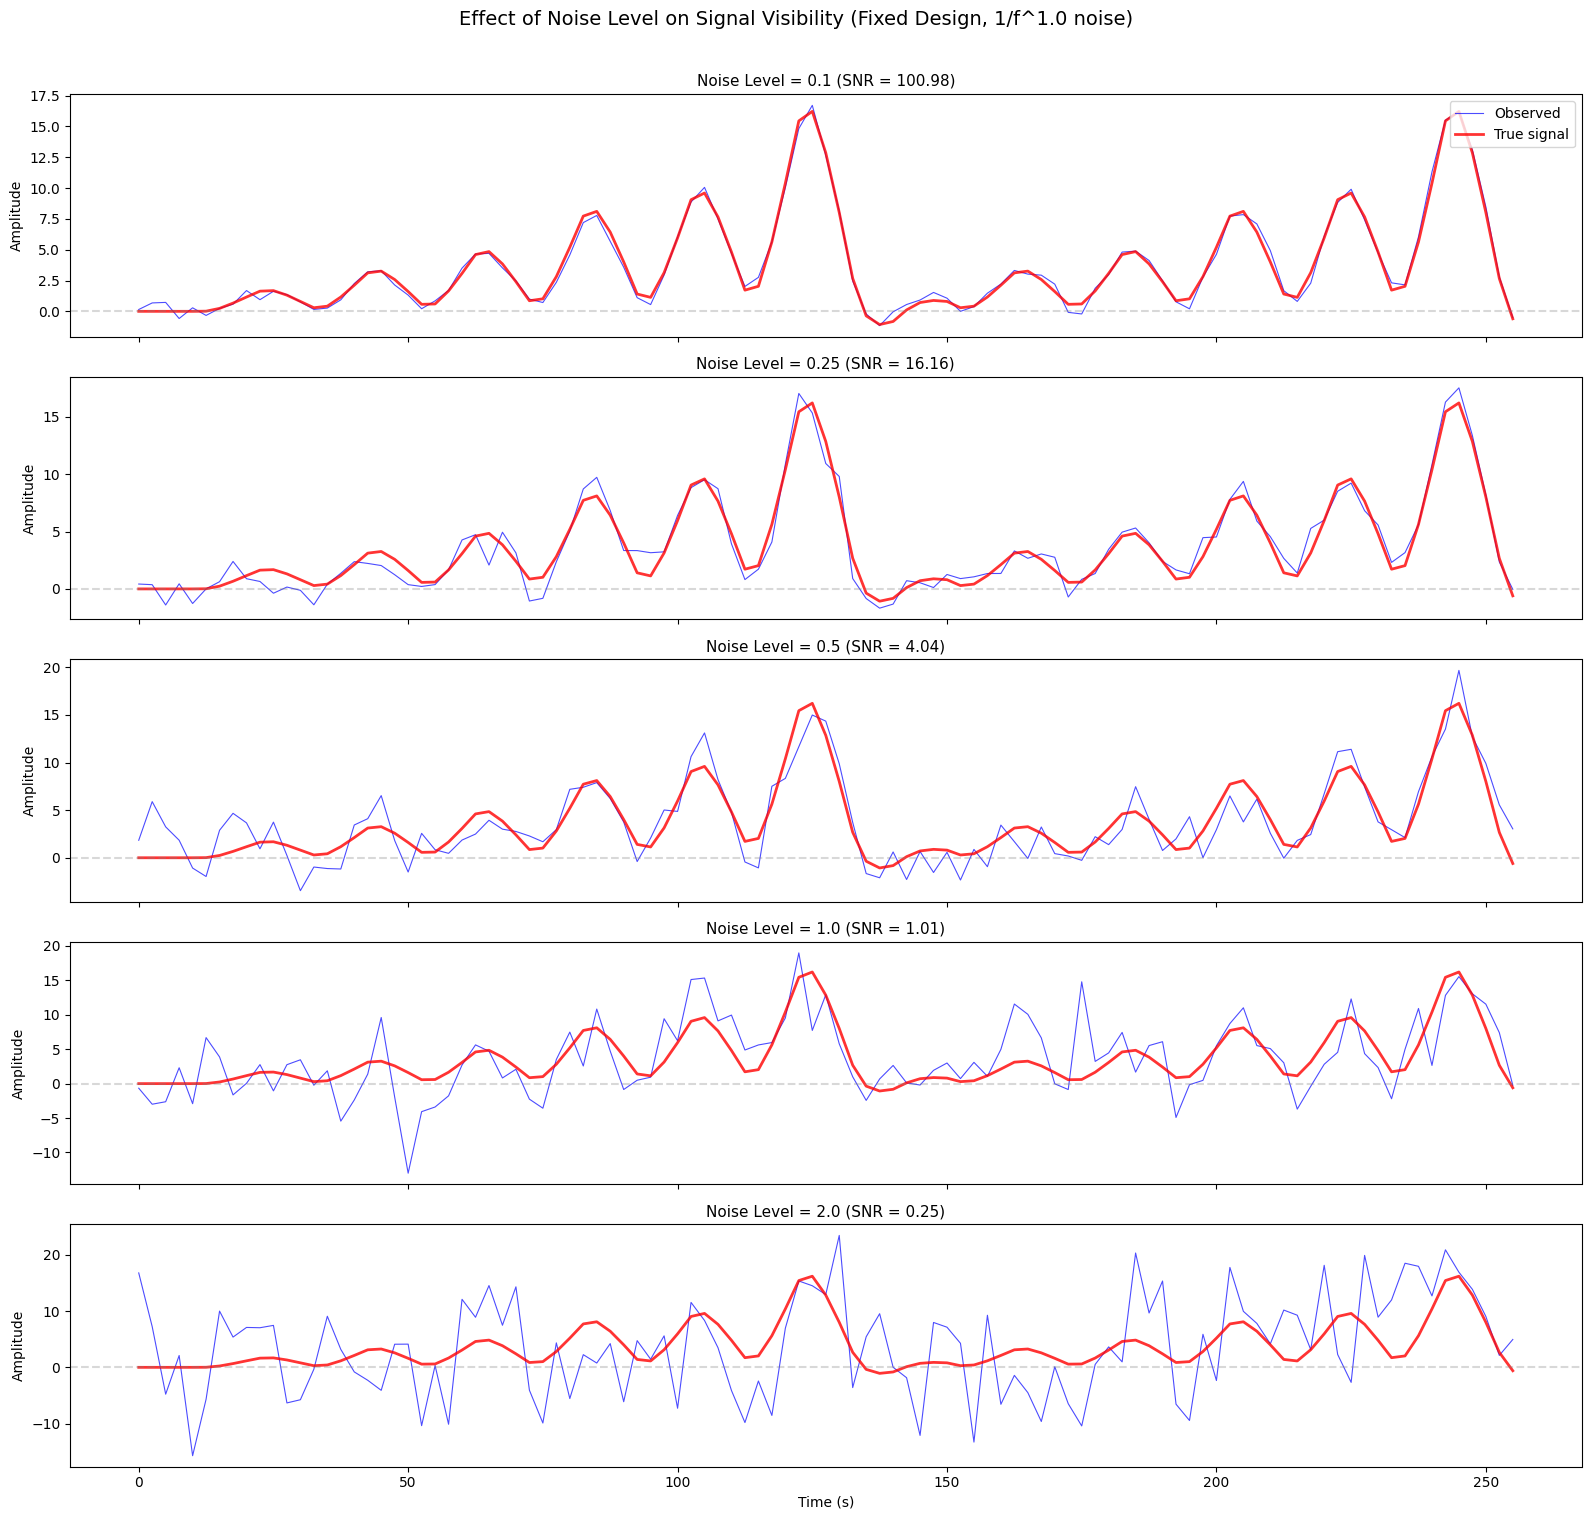

In [173]:
# Compare different noise levels visually (single run)
noise_levels_viz = [0.1, 0.25, 0.5, 1.0, 2.0]

# Use first design for demonstration
d = list(designs.values())[0]
design_name = list(designs.keys())[0]
n_tps = d['n_tps_per_run']
duration_s = n_tps * TR
time_axis = np.arange(n_tps) * TR

# Clean signal
betas_t = torch.tensor(TRUE_BETAS, device=device)
clean_signal = (d['design_sim_single'] @ betas_t).cpu().numpy()

fig, axes = plt.subplots(len(noise_levels_viz), 1, figsize=(16, 3*len(noise_levels_viz)), sharex=True)

for ax, noise_lvl in zip(axes, noise_levels_viz):
    # Generate noise
    noise = ffs.generate_fmri_noise(
        tr=TR, duration_s=duration_s, matrix_size=(1, 1),
        pink_exp=PINK_EXPONENT, resp_strength=0.0, cardiac_strength=0.0,
        normalize=True, device=device
    ).cpu().numpy().flatten()
    
    # Scale noise
    scaled_noise = noise * noise_lvl * clean_signal.std()
    combined = clean_signal + scaled_noise
    
    # Calculate SNR
    snr = clean_signal.std()**2 / (scaled_noise.std()**2 + 1e-10)
    
    ax.plot(time_axis, combined, 'b-', linewidth=0.8, alpha=0.7, label='Observed')
    ax.plot(time_axis, clean_signal, 'r-', linewidth=2, alpha=0.8, label='True signal')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'Noise Level = {noise_lvl} (SNR = {snr:.2f})', fontsize=11)
    
    if ax == axes[0]:
        ax.legend(loc='upper right')

axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Effect of Noise Level on Signal Visibility ({design_name} Design, 1/f^{PINK_EXPONENT} noise)', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## All Designs: Signal vs Observed Data

Compare how the signal looks across all designs at the current noise level.

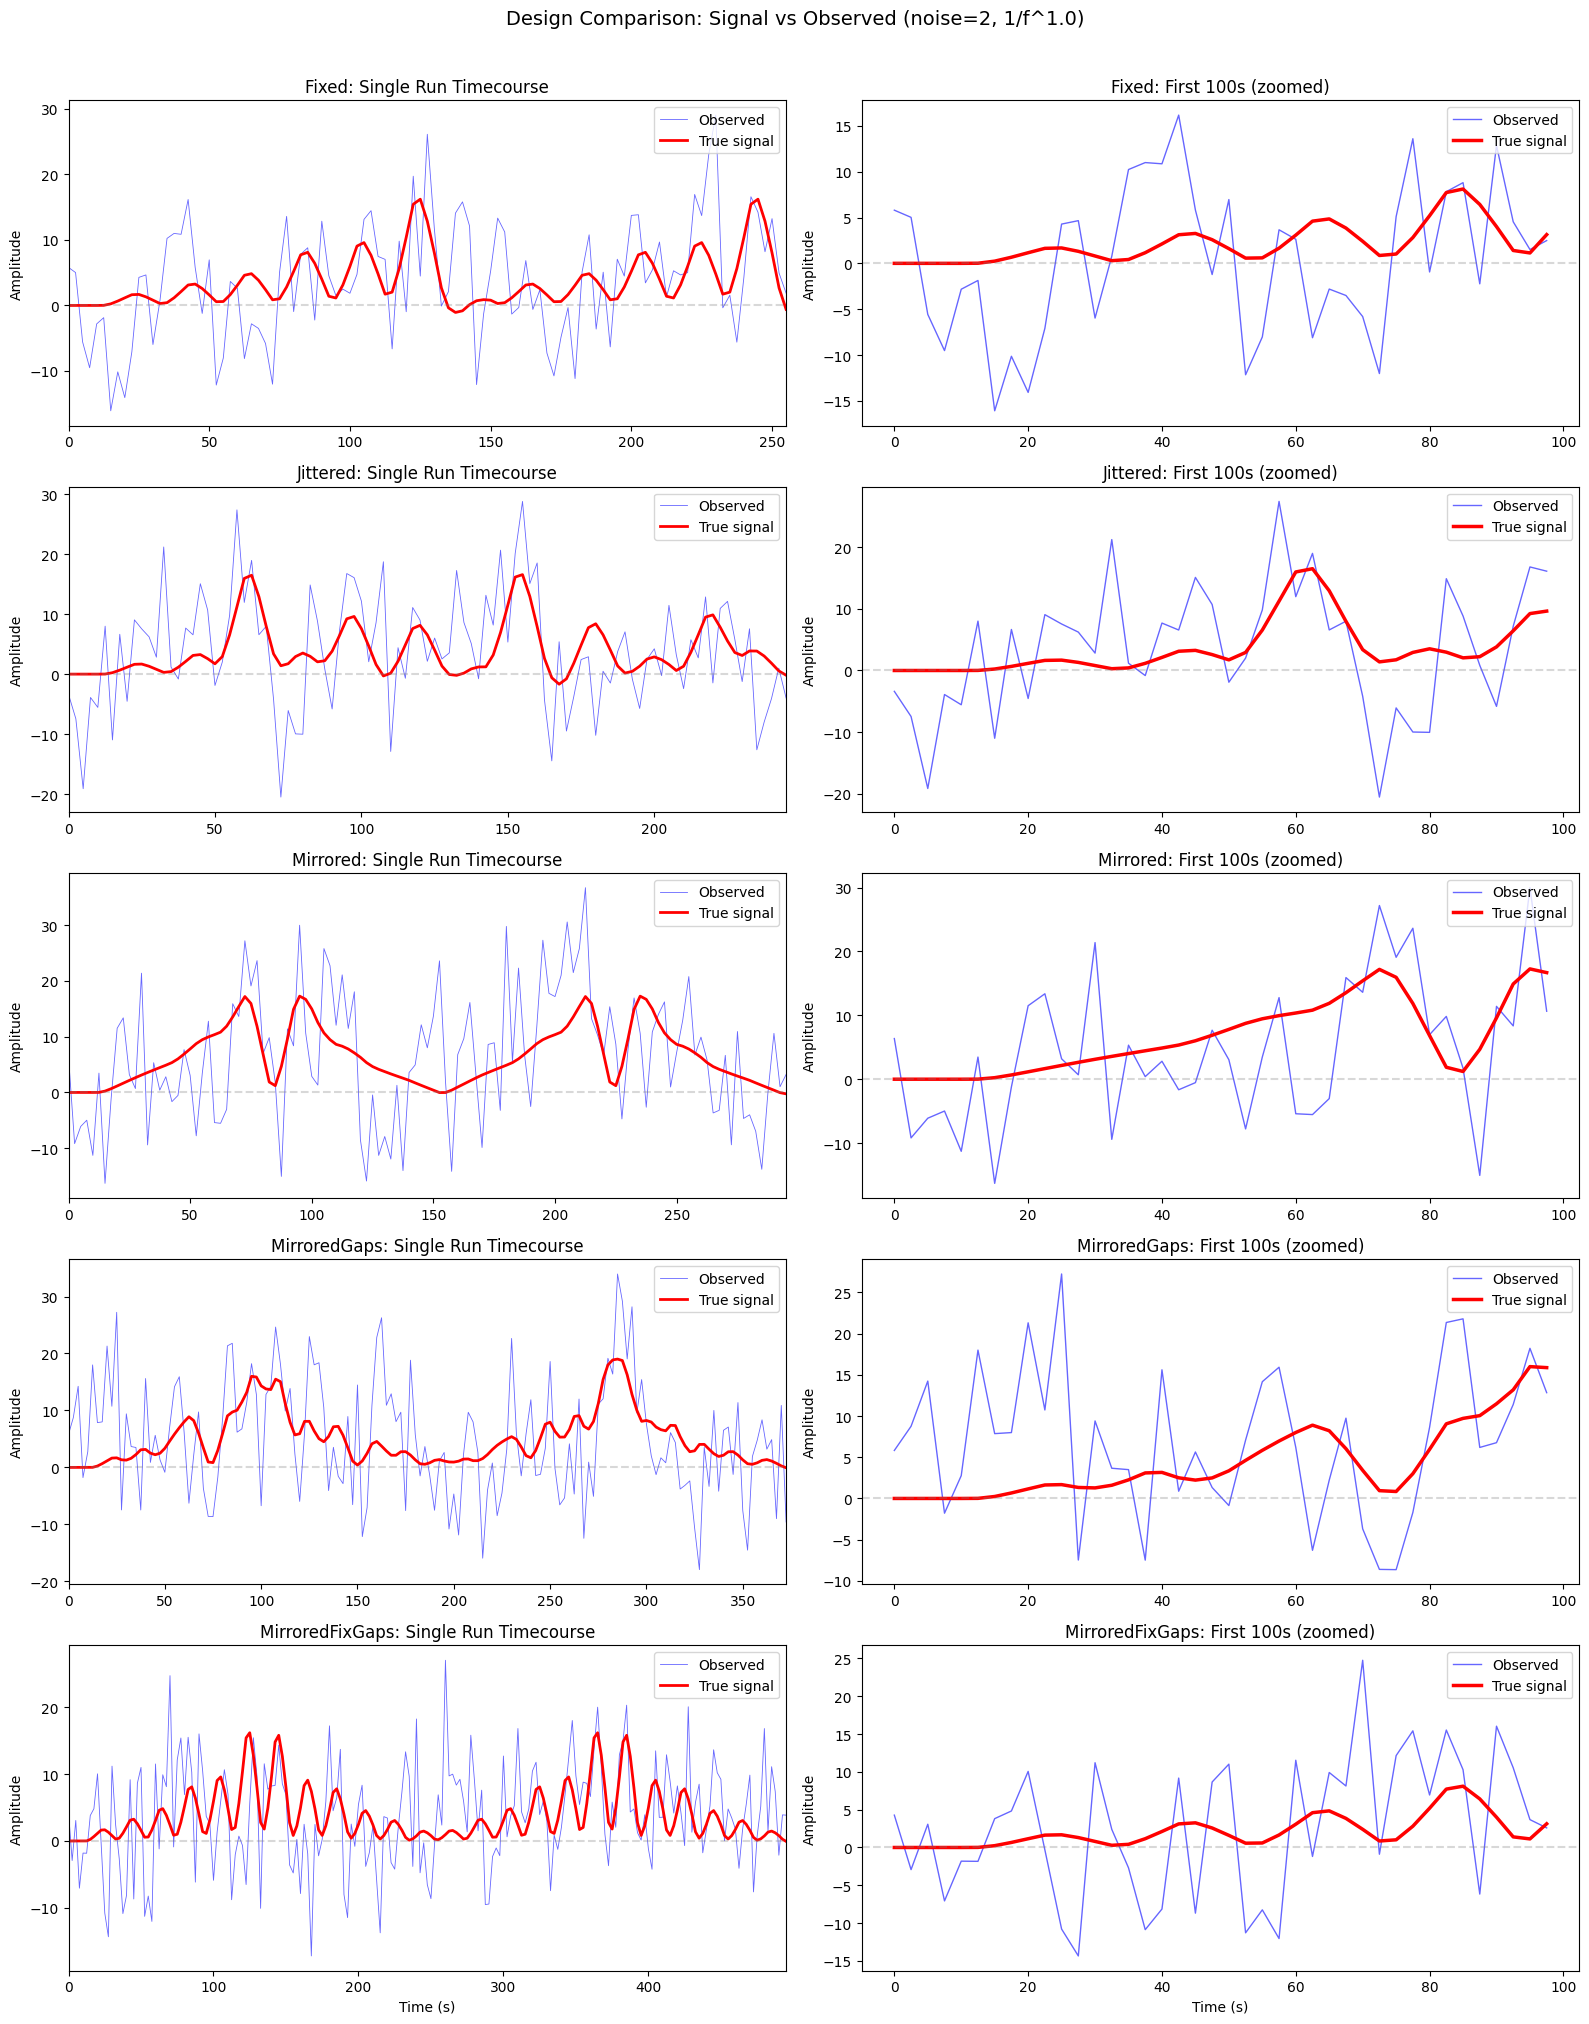

In [174]:
# Side-by-side comparison of all designs (single run for clarity)
fig, axes = plt.subplots(n_designs, 2, figsize=(16, 4*n_designs))
if n_designs == 1:
    axes = axes.reshape(1, 2)

betas_t = torch.tensor(TRUE_BETAS, device=device)

for row, (name, d) in enumerate(designs.items()):
    # Use first run for visualization
    data_run1 = d['data_runs'][0]
    n_tps = d['n_tps_per_run']
    time_axis = np.arange(n_tps) * TR
    clean_signal = (d['design_sim_single'] @ betas_t).cpu().numpy()
    observed = data_run1[0].cpu().numpy() - 100.0  # Remove baseline, single voxel
    
    # Left: Full timecourse
    ax = axes[row, 0]
    ax.plot(time_axis, observed, 'b-', linewidth=0.6, alpha=0.6, label='Observed')
    ax.plot(time_axis, clean_signal, 'r-', linewidth=2, label='True signal')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'{name}: Single Run Timecourse')
    ax.legend(loc='upper right')
    ax.set_xlim(0, time_axis[-1])
    
    # Right: Zoomed view (first ~100s)
    ax = axes[row, 1]
    zoom_end = min(40, len(time_axis))  # First 40 TRs = 100s at TR=2.5
    ax.plot(time_axis[:zoom_end], observed[:zoom_end], 'b-', linewidth=1, alpha=0.6, label='Observed')
    ax.plot(time_axis[:zoom_end], clean_signal[:zoom_end], 'r-', linewidth=2.5, label='True signal')
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.set_ylabel('Amplitude')
    ax.set_title(f'{name}: First {zoom_end * TR:.0f}s (zoomed)')
    ax.legend(loc='upper right')

axes[-1, 0].set_xlabel('Time (s)')
axes[-1, 1].set_xlabel('Time (s)')

plt.suptitle(f'Design Comparison: Signal vs Observed (noise={NOISE_LEVEL}, 1/f^{PINK_EXPONENT})', 
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## GLM Fitting

In [175]:
# Fit GLM for each design (multi-run, concatenated)
print("Fitting multi-run GLMs...\n")

for name, d in designs.items():
    results = ffs.fit_glm(
        data=d['data'],
        design=d['design_full'],
        tr=TR,
        max_poly_degree=None,  # We already included polynomials
        device=device,
        verbose=False
    )
    d['results'] = results
    
    # Extract task betas only (first N_EVENTS columns)
    d['betas_est'] = results.betas[:, :N_EVENTS]
    
    print(f"{name}: R²={results.r2.mean():.4f}, "
          f"Est betas={d['betas_est'].mean(dim=0).cpu().numpy()}")

Fitting multi-run GLMs...

Fixed: R²=0.2992, Est betas=[0.3892 0.9725 1.4794 2.4776 2.9609 4.9908]
Jittered: R²=0.3008, Est betas=[0.4898 0.9598 1.4153 2.5116 3.0445 5.111 ]
Mirrored: R²=0.2961, Est betas=[0.5245 1.0236 1.5718 2.5287 3.1601 5.0638]
MirroredGaps: R²=0.2819, Est betas=[0.5132 1.0726 1.5456 2.5348 3.022  5.1121]
MirroredFixGaps: R²=0.2663, Est betas=[0.4422 0.944  1.4292 2.4352 2.9248 4.9473]


## Run-Averaged GLM Analysis

Alternative approach: average data across runs first, then fit a single-run GLM.
This is simpler but loses some information about run-to-run variability.

In [176]:
# Run-averaged GLM: Average data across runs, then fit single-run design
print("Fitting run-averaged GLMs...\n")

for name, d in designs.items():
    # Average data across runs
    data_runs = d['data_runs']  # List of (n_voxels, n_tps_per_run)
    data_stacked = torch.stack(data_runs, dim=0)  # (n_runs, n_voxels, n_tps_per_run)
    data_averaged = data_stacked.mean(dim=0)  # (n_voxels, n_tps_per_run)
    
    # Build single-run design with polynomials
    design_single_with_poly = torch.cat([
        d['design_glm_single'],
        build_polynomial_regressors(d['n_tps_per_run'], POLY_ORDER)
    ], dim=1)
    
    # Fit GLM on averaged data
    results_avg = ffs.fit_glm(
        data=data_averaged,
        design=design_single_with_poly,
        tr=TR,
        max_poly_degree=None,
        device=device,
        verbose=False
    )
    
    d['results_averaged'] = results_avg
    d['betas_est_averaged'] = results_avg.betas[:, :N_EVENTS]
    
    print(f"{name}: R²={results_avg.r2.mean():.4f}, "
          f"Est betas={d['betas_est_averaged'].mean(dim=0).cpu().numpy()}")

print("\n" + "=" * 70)
print("Comparison: Multi-Run vs Run-Averaged GLM")
print("=" * 70)
print(f"{'Design':<15} {'Multi-Run R²':>15} {'Averaged R²':>15} {'Difference':>15}")
print("-" * 70)
for name, d in designs.items():
    r2_multi = d['results'].r2.mean().item()
    r2_avg = d['results_averaged'].r2.mean().item()
    print(f"{name:<15} {r2_multi:>15.4f} {r2_avg:>15.4f} {r2_multi - r2_avg:>+15.4f}")
print("=" * 70)
print("\nNote: Multi-run GLM uses all data; averaged GLM loses run-to-run variability info")

Fitting run-averaged GLMs...

Fixed: R²=0.7052, Est betas=[0.396  0.9874 1.4888 2.4809 2.9573 4.9817]
Jittered: R²=0.7091, Est betas=[0.4925 0.9718 1.3944 2.5204 3.0551 5.119 ]
Mirrored: R²=0.7006, Est betas=[0.5383 1.0263 1.5779 2.5346 3.1639 5.0661]
MirroredGaps: R²=0.6909, Est betas=[0.5361 1.0701 1.539  2.5334 3.0329 5.1003]
MirroredFixGaps: R²=0.6816, Est betas=[0.4466 0.9496 1.4471 2.4229 2.9047 4.9285]

Comparison: Multi-Run vs Run-Averaged GLM
Design             Multi-Run R²     Averaged R²      Difference
----------------------------------------------------------------------
Fixed                    0.2992          0.7052         -0.4060
Jittered                 0.3008          0.7091         -0.4083
Mirrored                 0.2961          0.7006         -0.4045
MirroredGaps             0.2819          0.6909         -0.4090
MirroredFixGaps          0.2663          0.6816         -0.4153

Note: Multi-run GLM uses all data; averaged GLM loses run-to-run variability info


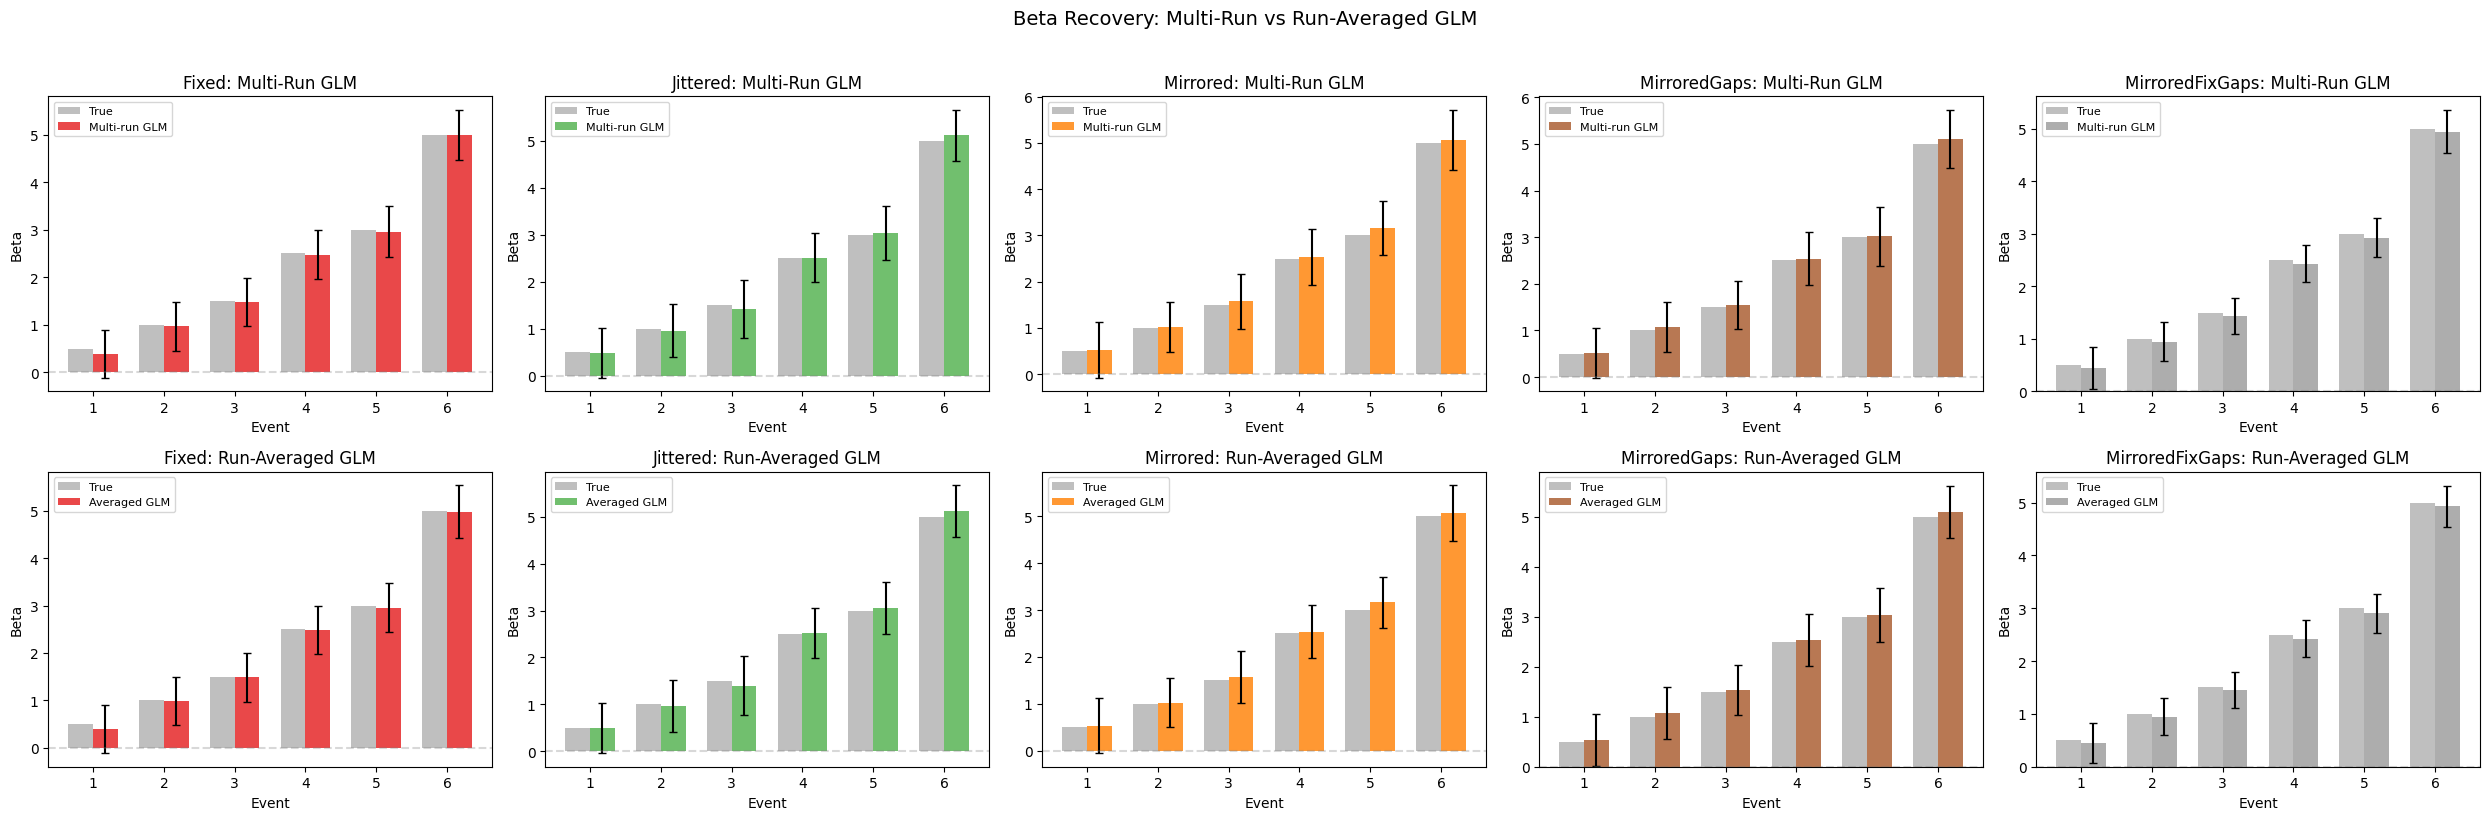


Beta Recovery Correlation with True Betas:
Design              Multi-Run r      Averaged r
--------------------------------------------------
Fixed                    0.9998          0.9998
Jittered                 0.9998          0.9996
Mirrored                 0.9996          0.9996
MirroredGaps             0.9998          0.9999
MirroredFixGaps          1.0000          1.0000


In [177]:
# Visualize: Multi-Run vs Averaged GLM beta estimates
fig, axes = plt.subplots(2, n_designs, figsize=(5*n_designs, 8))
if n_designs == 1:
    axes = axes.reshape(2, 1)

design_colors_map = plt.cm.Set1(np.linspace(0, 1, n_designs))

for col, (name, d) in enumerate(designs.items()):
    # Top row: Multi-run GLM
    ax = axes[0, col]
    x = np.arange(N_EVENTS)
    width = 0.35
    
    betas_multi = d['betas_est'].mean(dim=0).cpu().numpy()
    betas_multi_std = d['betas_est'].std(dim=0).cpu().numpy()
    
    ax.bar(x - width/2, TRUE_BETAS, width, label='True', color='gray', alpha=0.5)
    ax.bar(x + width/2, betas_multi, width, label='Multi-run GLM', 
          color=design_colors_map[col], alpha=0.8)
    ax.errorbar(x + width/2, betas_multi, yerr=betas_multi_std, fmt='none', 
               color='black', capsize=3)
    
    ax.set_xlabel('Event')
    ax.set_ylabel('Beta')
    ax.set_title(f'{name}: Multi-Run GLM')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{i+1}' for i in range(N_EVENTS)])
    ax.legend(loc='upper left', fontsize=8)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    
    # Bottom row: Run-averaged GLM
    ax = axes[1, col]
    
    betas_avg = d['betas_est_averaged'].mean(dim=0).cpu().numpy()
    betas_avg_std = d['betas_est_averaged'].std(dim=0).cpu().numpy()
    
    ax.bar(x - width/2, TRUE_BETAS, width, label='True', color='gray', alpha=0.5)
    ax.bar(x + width/2, betas_avg, width, label='Averaged GLM', 
          color=design_colors_map[col], alpha=0.8)
    ax.errorbar(x + width/2, betas_avg, yerr=betas_avg_std, fmt='none', 
               color='black', capsize=3)
    
    ax.set_xlabel('Event')
    ax.set_ylabel('Beta')
    ax.set_title(f'{name}: Run-Averaged GLM')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{i+1}' for i in range(N_EVENTS)])
    ax.legend(loc='upper left', fontsize=8)
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)

plt.suptitle('Beta Recovery: Multi-Run vs Run-Averaged GLM', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Also show correlation comparison
print("\nBeta Recovery Correlation with True Betas:")
print(f"{'Design':<15} {'Multi-Run r':>15} {'Averaged r':>15}")
print("-" * 50)
for name, d in designs.items():
    betas_multi = d['betas_est'].mean(dim=0).cpu().numpy()
    betas_avg = d['betas_est_averaged'].mean(dim=0).cpu().numpy()
    r_multi = np.corrcoef(betas_multi, TRUE_BETAS)[0, 1]
    r_avg = np.corrcoef(betas_avg, TRUE_BETAS)[0, 1]
    print(f"{name:<15} {r_multi:>15.4f} {r_avg:>15.4f}")

## Beta Recovery Analysis

In [178]:
def compute_recovery_metrics(est_betas: torch.Tensor, true_betas: List[float]) -> dict:
    """
    Compute beta recovery quality metrics.
    """
    est = est_betas.cpu().numpy()
    true = np.array(true_betas)
    est_mean = est.mean(axis=0)
    
    return {
        'rmse': np.sqrt(((est_mean - true) ** 2).mean()),
        'correlation': np.corrcoef(est_mean, true)[0, 1],
        'bias': (est_mean - true).mean(),
        'std': est.std(axis=0).mean(),  # Variability across voxels
        'est_mean': est_mean,
        'est_all': est
    }


# Compute metrics
print("\nBeta Recovery Metrics")
print("=" * 70)
print(f"True betas: {TRUE_BETAS}")
print("=" * 70)

for name, d in designs.items():
    m = compute_recovery_metrics(d['betas_est'], TRUE_BETAS)
    d['metrics'] = m
    print(f"\n{name}:")
    print(f"  RMSE={m['rmse']:.4f}, Corr={m['correlation']:.4f}, "
          f"Bias={m['bias']:.4f}, Std={m['std']:.4f}")
    print(f"  Estimated: {m['est_mean']}")


Beta Recovery Metrics
True betas: [0.5, 1.0, 1.5, 2.5, 3.0, 5.0]

Fixed:
  RMSE=0.0510, Corr=0.9998, Bias=-0.0383, Std=0.5199
  Estimated: [0.3892 0.9725 1.4794 2.4776 2.9609 4.9908]

Jittered:
  RMSE=0.0624, Corr=0.9998, Bias=0.0053, Std=0.5594
  Estimated: [0.4898 0.9598 1.4153 2.5116 3.0445 5.111 ]

Mirrored:
  RMSE=0.0784, Corr=0.9996, Bias=0.0621, Std=0.5971
  Estimated: [0.5245 1.0236 1.5718 2.5287 3.1601 5.0638]

MirroredGaps:
  RMSE=0.0603, Corr=0.9998, Bias=0.0501, Std=0.5693
  Estimated: [0.5132 1.0726 1.5456 2.5348 3.022  5.1121]

MirroredFixGaps:
  RMSE=0.0634, Corr=1.0000, Bias=-0.0629, Std=0.3739
  Estimated: [0.4422 0.944  1.4292 2.4352 2.9248 4.9473]


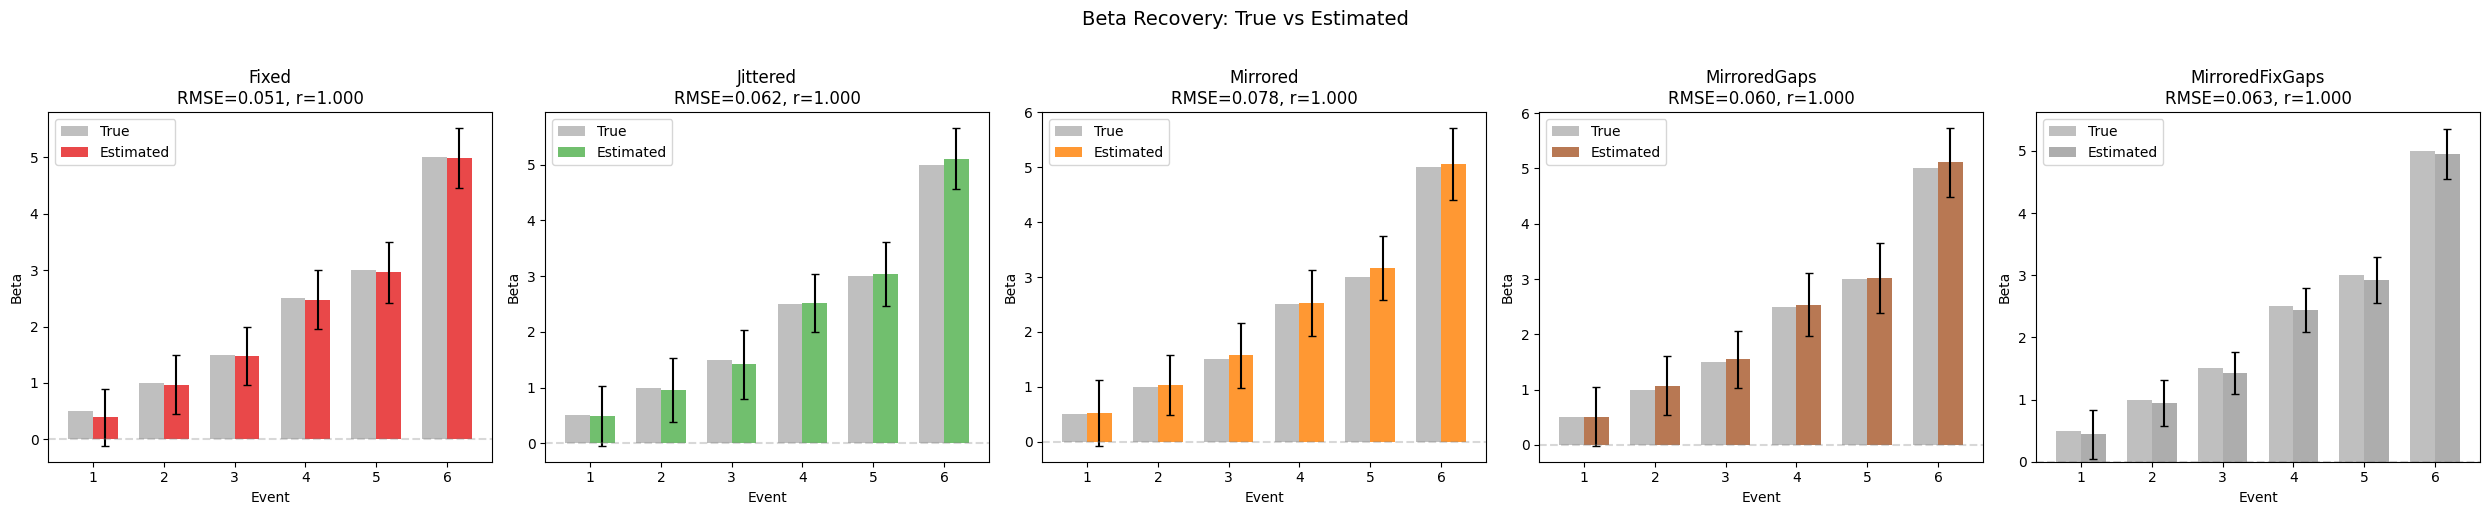

In [179]:
# Visualize beta recovery
fig, axes = plt.subplots(1, n_designs, figsize=(5*n_designs, 5))
if n_designs == 1:
    axes = [axes]

design_colors_map = plt.cm.Set1(np.linspace(0, 1, n_designs))

for ax, (i, (name, d)) in zip(axes, enumerate(designs.items())):
    x = np.arange(N_EVENTS)
    width = 0.35
    
    m = d['metrics']
    
    # True betas
    ax.bar(x - width/2, TRUE_BETAS, width, label='True', color='gray', alpha=0.5)
    
    # Estimated betas
    ax.bar(x + width/2, m['est_mean'], width, label='Estimated', 
          color=design_colors_map[i], alpha=0.8)
    
    # Error bars (std across voxels)
    est_std = d['betas_est'].std(dim=0).cpu().numpy()
    ax.errorbar(x + width/2, m['est_mean'], yerr=est_std, fmt='none', 
               color='black', capsize=3, capthick=1)
    
    ax.set_xlabel('Event')
    ax.set_ylabel('Beta')
    ax.set_title(f'{name}\nRMSE={m["rmse"]:.3f}, r={m["correlation"]:.3f}')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{i+1}' for i in range(N_EVENTS)])
    ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
    ax.legend(loc='upper left')

plt.suptitle('Beta Recovery: True vs Estimated', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

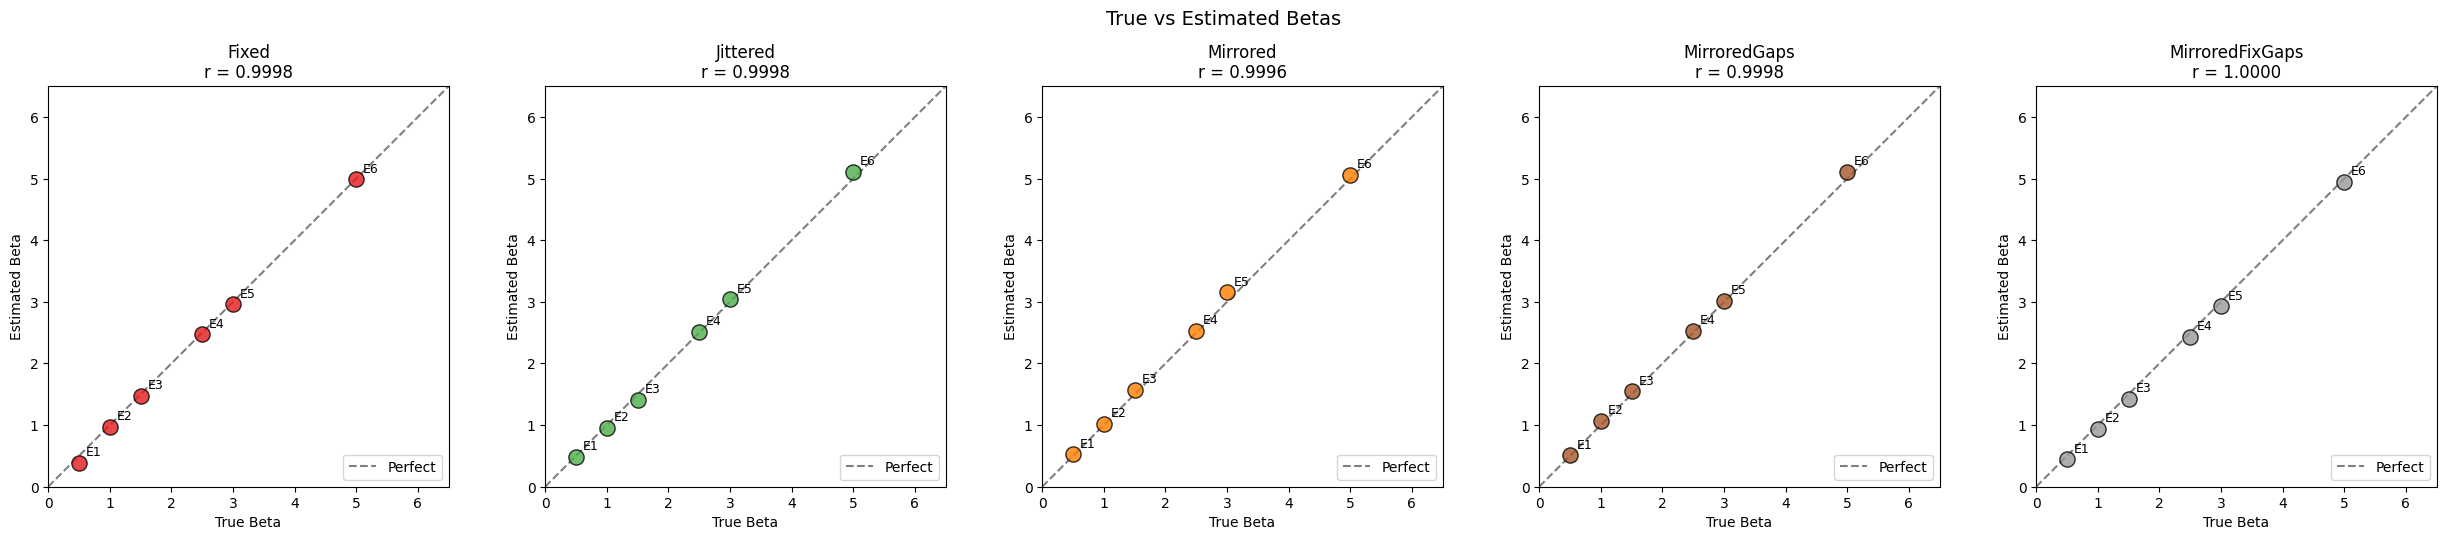

In [180]:
# Scatter plot: True vs Estimated
fig, axes = plt.subplots(1, n_designs, figsize=(5*n_designs, 5))
if n_designs == 1:
    axes = [axes]

for ax, (i, (name, d)) in zip(axes, enumerate(designs.items())):
    m = d['metrics']
    
    ax.scatter(TRUE_BETAS, m['est_mean'], s=120, c=[design_colors_map[i]], 
              edgecolors='black', alpha=0.8, zorder=5)
    
    # Identity line
    lims = [0, max(TRUE_BETAS) * 1.3]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect')
    
    # Label points
    for j, (t, e) in enumerate(zip(TRUE_BETAS, m['est_mean'])):
        ax.annotate(f'E{j+1}', (t, e), xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    ax.set_xlabel('True Beta')
    ax.set_ylabel('Estimated Beta')
    ax.set_title(f'{name}\nr = {m["correlation"]:.4f}')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_aspect('equal')
    ax.legend(loc='lower right')

plt.suptitle('True vs Estimated Betas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## T-Statistics and Detection Power

The GLM gives us t-statistics for free. This tells us: "Of the 1000 simulated voxels, how many would be detected as significantly active?"

Degrees of freedom: 687
Critical t-values (two-tailed):
  α = 0.05: |t| > 1.963
  α = 0.01: |t| > 2.583
  α = 0.001: |t| > 3.305



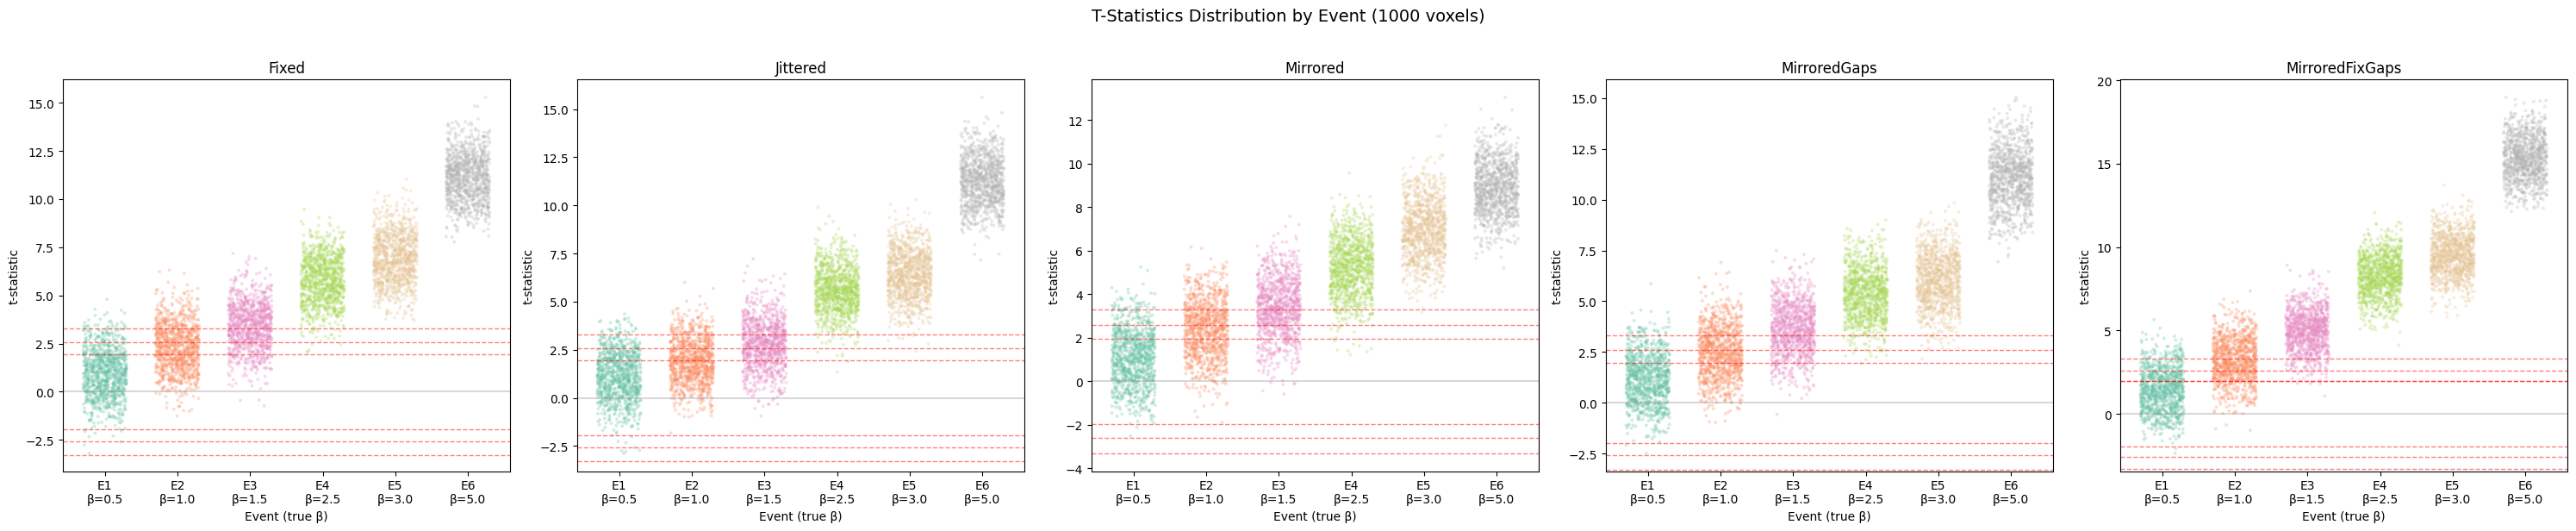

In [181]:
from scipy import stats as scipy_stats

# Get degrees of freedom from the GLM results
# df = n_timepoints - n_regressors
example_design = list(designs.values())[0]['design_full']
n_tps_total = example_design.shape[0]
n_regressors = example_design.shape[1]
df = n_tps_total - n_regressors

# Critical t-values for different alpha levels (two-tailed)
alpha_levels = [0.05, 0.01, 0.001]
t_crits = {alpha: scipy_stats.t.ppf(1 - alpha/2, df) for alpha in alpha_levels}

print(f"Degrees of freedom: {df}")
print(f"Critical t-values (two-tailed):")
for alpha, t_crit in t_crits.items():
    print(f"  α = {alpha}: |t| > {t_crit:.3f}")
print()

# T-stat swarm plot for each design
fig, axes = plt.subplots(1, n_designs, figsize=(6*n_designs, 6))
if n_designs == 1:
    axes = [axes]

for ax, (name, d) in zip(axes, designs.items()):
    # Get t-stats for task regressors
    tstats = d['results'].tstats[:, :N_EVENTS].cpu().numpy()  # (n_voxels, n_events)
    
    # Prepare data for swarm plot
    x_positions = []
    y_values = []
    event_labels = []
    
    for event_id in range(N_EVENTS):
        event_tstats = tstats[:, event_id]
        x_positions.extend([event_id] * len(event_tstats))
        y_values.extend(event_tstats)
        event_labels.extend([f'E{event_id+1}'] * len(event_tstats))
    
    # Jittered strip plot (like swarm but faster)
    for event_id in range(N_EVENTS):
        event_tstats = tstats[:, event_id]
        jitter = np.random.uniform(-0.3, 0.3, len(event_tstats))
        ax.scatter(event_id + jitter, event_tstats, alpha=0.3, s=8, 
                  c=[colors[event_id]], edgecolors='none')
    
    # Add horizontal lines for significance thresholds
    for alpha, t_crit in t_crits.items():
        ax.axhline(t_crit, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.axhline(-t_crit, color='red', linestyle='--', alpha=0.5, linewidth=1)
    
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.set_xticks(range(N_EVENTS))
    ax.set_xticklabels([f'E{i+1}\nβ={TRUE_BETAS[i]}' for i in range(N_EVENTS)])
    ax.set_xlabel('Event (true β)')
    ax.set_ylabel('t-statistic')
    ax.set_title(f'{name}')

# Add legend to last plot
ax.axhline(t_crits[0.05], color='red', linestyle='--', alpha=0.5, linewidth=1, 
          label=f'α=0.05 (t={t_crits[0.05]:.2f})')

plt.suptitle(f'T-Statistics Distribution by Event ({N_VOXELS} voxels)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [182]:
# Detection Power Summary: What % of voxels are significant at each alpha level?
print("=" * 90)
print("DETECTION POWER SUMMARY (% of voxels significant, two-tailed)")
print("=" * 90)

# Create summary table
for name, d in designs.items():
    tstats = d['results'].tstats[:, :N_EVENTS].cpu().numpy()  # (n_voxels, n_events)
    
    print(f"\n{name}:")
    print(f"{'Event':<10} {'True β':<10} {'Mean t':<12}", end="")
    for alpha in alpha_levels:
        print(f"{'α=' + str(alpha):>12}", end="")
    print()
    print("-" * 70)
    
    for event_id in range(N_EVENTS):
        event_tstats = tstats[:, event_id]
        mean_t = event_tstats.mean()
        
        print(f"E{event_id+1:<9} {TRUE_BETAS[event_id]:<10.1f} {mean_t:<12.2f}", end="")
        
        for alpha in alpha_levels:
            t_crit = t_crits[alpha]
            pct_sig = 100 * (np.abs(event_tstats) > t_crit).mean()
            print(f"{pct_sig:>11.1f}%", end="")
        print()
    
    # Overall summary for this design
    print("-" * 70)
    mean_pcts = {}
    for alpha in alpha_levels:
        t_crit = t_crits[alpha]
        pct_sig = 100 * (np.abs(tstats) > t_crit).mean()
        mean_pcts[alpha] = pct_sig
    print(f"{'Overall':<10} {'':<10} {'':<12}", end="")
    for alpha in alpha_levels:
        print(f"{mean_pcts[alpha]:>11.1f}%", end="")
    print()

print("\n" + "=" * 90)
print("Interpretation:")
print(f"  - At α=0.05, we expect ~5% false positives under the null hypothesis")
print(f"  - Higher true β → higher t-statistic → more voxels detected as significant")
print(f"  - Lower noise level → higher t-statistics → better detection power")
print("=" * 90)

DETECTION POWER SUMMARY (% of voxels significant, two-tailed)

Fixed:
Event      True β     Mean t            α=0.05      α=0.01     α=0.001
----------------------------------------------------------------------
E1         0.5        0.95               20.2%       10.2%        2.7%
E2         1.0        2.29               59.2%       40.7%       20.1%
E3         1.5        3.42               88.3%       76.7%       54.9%
E4         2.5        5.76              100.0%       99.5%       97.6%
E5         3.0        6.91              100.0%      100.0%      100.0%
E6         5.0        11.12             100.0%      100.0%      100.0%
----------------------------------------------------------------------
Overall                                  78.0%       71.2%       62.5%

Jittered:
Event      True β     Mean t            α=0.05      α=0.01     α=0.001
----------------------------------------------------------------------
E1         0.5        1.12               27.2%       12.2%        3

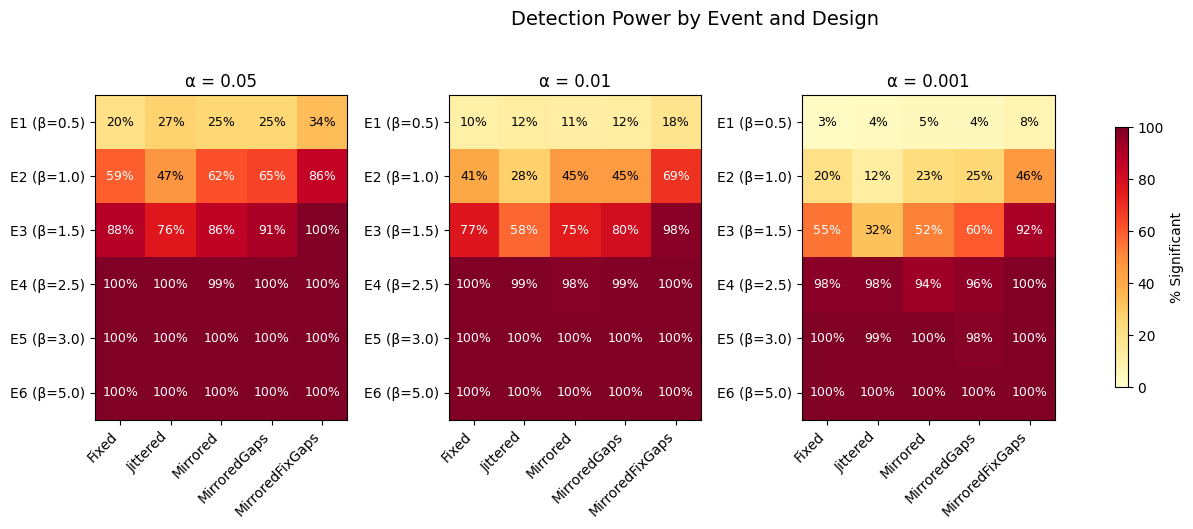

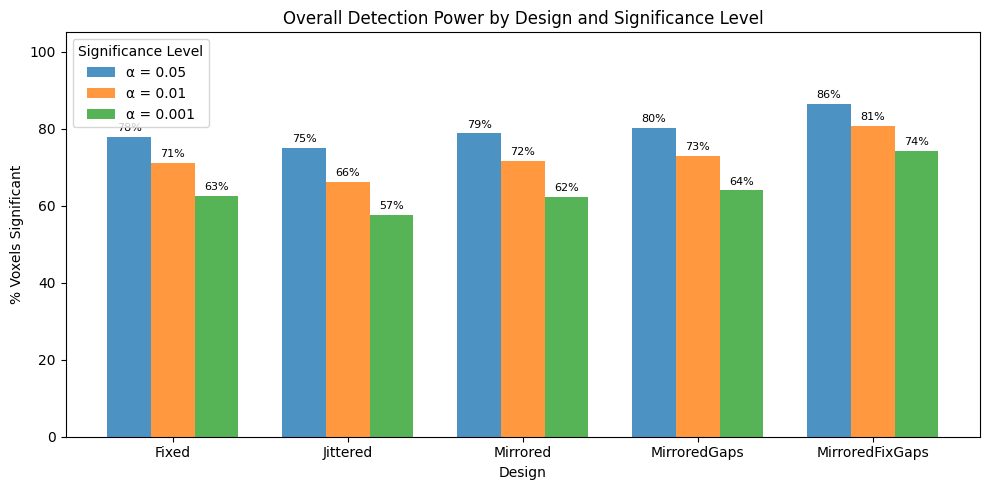

In [183]:
# Visualization: Detection Power Heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Collect data for heatmaps
for ax_idx, alpha in enumerate(alpha_levels):
    t_crit = t_crits[alpha]
    ax = axes[ax_idx]
    
    # Build heatmap data: rows = events, cols = designs
    heatmap_data = np.zeros((N_EVENTS, n_designs))
    
    for col_idx, (name, d) in enumerate(designs.items()):
        tstats = d['results'].tstats[:, :N_EVENTS].cpu().numpy()
        for event_id in range(N_EVENTS):
            pct_sig = 100 * (np.abs(tstats[:, event_id]) > t_crit).mean()
            heatmap_data[event_id, col_idx] = pct_sig
    
    # Plot heatmap
    im = ax.imshow(heatmap_data, cmap='YlOrRd', aspect='auto', vmin=0, vmax=100)
    
    # Labels
    ax.set_xticks(range(n_designs))
    ax.set_xticklabels(list(designs.keys()), rotation=45, ha='right')
    ax.set_yticks(range(N_EVENTS))
    ax.set_yticklabels([f'E{i+1} (β={TRUE_BETAS[i]})' for i in range(N_EVENTS)])
    ax.set_title(f'α = {alpha}')
    
    # Add text annotations
    for i in range(N_EVENTS):
        for j in range(n_designs):
            val = heatmap_data[i, j]
            color = 'white' if val > 50 else 'black'
            ax.text(j, i, f'{val:.0f}%', ha='center', va='center', color=color, fontsize=9)

# pad out the subplots so there is space for axes labels, pad isn't available here
plt.subplots_adjust(left=0.1, right=0.9, top=0.85, bottom=0.2, wspace=0.4)

plt.colorbar(im, ax=axes, shrink=0.8, label='% Significant')
plt.suptitle('Detection Power by Event and Design', fontsize=14, y=1.02)
# plt.tight_layout()
plt.show()

# Bar chart comparison: Overall detection power
fig, ax = plt.subplots(figsize=(10, 5))

bar_width = 0.25
x = np.arange(n_designs)

for i, alpha in enumerate(alpha_levels):
    t_crit = t_crits[alpha]
    pcts = []
    for name, d in designs.items():
        tstats = d['results'].tstats[:, :N_EVENTS].cpu().numpy()
        pct = 100 * (np.abs(tstats) > t_crit).mean()
        pcts.append(pct)
    
    offset = (i - 1) * bar_width
    bars = ax.bar(x + offset, pcts, bar_width, label=f'α = {alpha}', alpha=0.8)
    
    # Add value labels
    for bar, pct in zip(bars, pcts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
               f'{pct:.0f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(list(designs.keys()))
ax.set_ylabel('% Voxels Significant')
ax.set_xlabel('Design')
ax.set_title('Overall Detection Power by Design and Significance Level')
ax.legend(title='Significance Level')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.show()

## Summary Comparison

In [184]:
# Summary table
print("\n" + "=" * 90)
print("DESIGN COMPARISON SUMMARY (Multi-Run GLM)")
print("=" * 90)
print(f"{'Design':<15} {'TRs/run':>10} {'Corr(X)':>10} {'RMSE':>10} {'r(β)':>10} {'Bias':>10}")
print("-" * 90)

for name, d in designs.items():
    m = d['metrics']
    n_tps_per_run = d['n_tps_per_run']
    corr_x = design_correlations[name]
    print(f"{name:<15} {n_tps_per_run:>10} {corr_x:>10.4f} {m['rmse']:>10.4f} "
          f"{m['correlation']:>10.4f} {m['bias']:>10.4f}")

print("=" * 90)
print(f"\nN_RUNS = {N_RUNS}, N_REPEATS_PER_RUN = {N_REPEATS_PER_RUN}")
print(f"Total repeats per condition = {N_RUNS * N_REPEATS_PER_RUN}")
print("\nCorr(X) = mean absolute off-diagonal correlation in design matrix")
print("RMSE = root mean squared error in beta estimates")
print("r(β) = correlation between true and estimated betas")


DESIGN COMPARISON SUMMARY (Multi-Run GLM)
Design             TRs/run    Corr(X)       RMSE       r(β)       Bias
------------------------------------------------------------------------------------------
Fixed                  103     0.1383     0.0510     0.9998    -0.0383
Jittered                99     0.1416     0.0624     0.9998     0.0053
Mirrored               119     0.1835     0.0784     0.9996     0.0621
MirroredGaps           150     0.1676     0.0603     0.9998     0.0501
MirroredFixGaps        199     0.1423     0.0634     1.0000    -0.0629

N_RUNS = 7, N_REPEATS_PER_RUN = 2
Total repeats per condition = 14

Corr(X) = mean absolute off-diagonal correlation in design matrix
RMSE = root mean squared error in beta estimates
r(β) = correlation between true and estimated betas


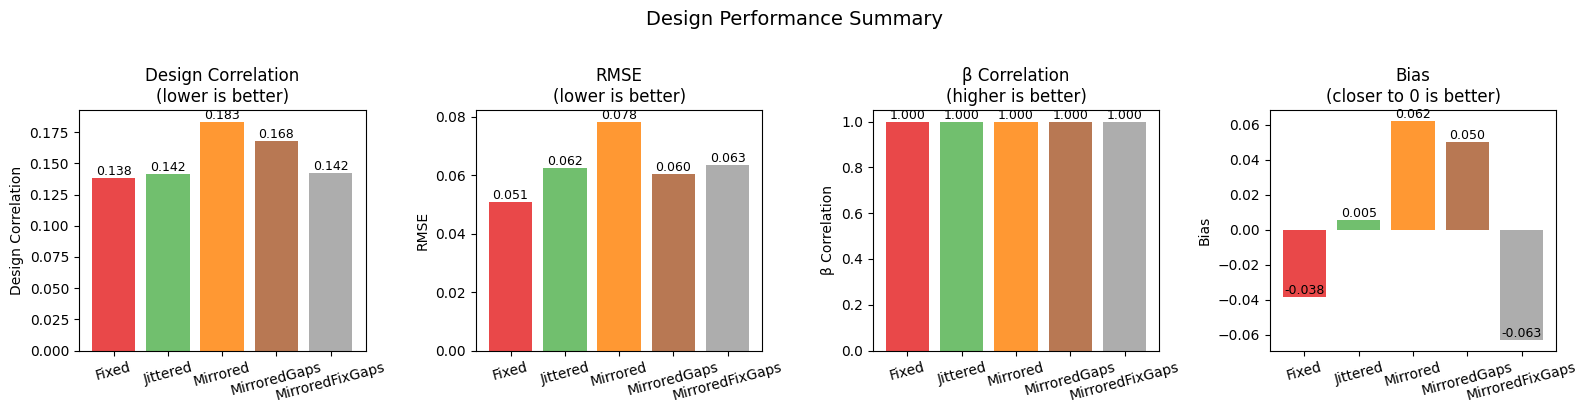

In [185]:
# Summary bar chart
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

design_names = list(designs.keys())
x = np.arange(len(design_names))

metrics_list = [
    ('Design Correlation', [design_correlations[n] for n in design_names], 'lower is better'),
    ('RMSE', [designs[n]['metrics']['rmse'] for n in design_names], 'lower is better'),
    ('β Correlation', [designs[n]['metrics']['correlation'] for n in design_names], 'higher is better'),
    ('Bias', [designs[n]['metrics']['bias'] for n in design_names], 'closer to 0 is better'),
]

for ax, (title, values, note) in zip(axes, metrics_list):
    bars = ax.bar(x, values, color=[design_colors_map[i] for i in range(len(design_names))], alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(design_names, rotation=15)
    ax.set_title(f'{title}\n({note})')
    ax.set_ylabel(title)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{val:.3f}',
               ha='center', va='bottom', fontsize=9)

plt.suptitle('Design Performance Summary', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Effect of Noise Level

In [186]:
noise_levels = [0.1, 0.25, 0.5, 1.0, 2.0]
noise_sweep_results = {name: {'noise': [], 'rmse': [], 'corr': []} for name in designs.keys()}

print("Running noise level sweep (multi-run GLM)...")

for noise in noise_levels:
    for name, d in designs.items():
        # Simulate multi-run
        data, _ = simulate_multirun_data(
            d['design_sim_single'], TRUE_BETAS, N_RUNS, noise, PINK_EXPONENT, N_VOXELS
        )
        
        # Fit multi-run GLM
        results = ffs.fit_glm(
            data=data, design=d['design_full'], tr=TR, 
            max_poly_degree=None, device=device, verbose=False
        )
        
        # Metrics
        betas_est = results.betas[:, :N_EVENTS]
        m = compute_recovery_metrics(betas_est, TRUE_BETAS)
        
        noise_sweep_results[name]['noise'].append(noise)
        noise_sweep_results[name]['rmse'].append(m['rmse'])
        noise_sweep_results[name]['corr'].append(m['correlation'])

print("Done!")

Running noise level sweep (multi-run GLM)...
Done!


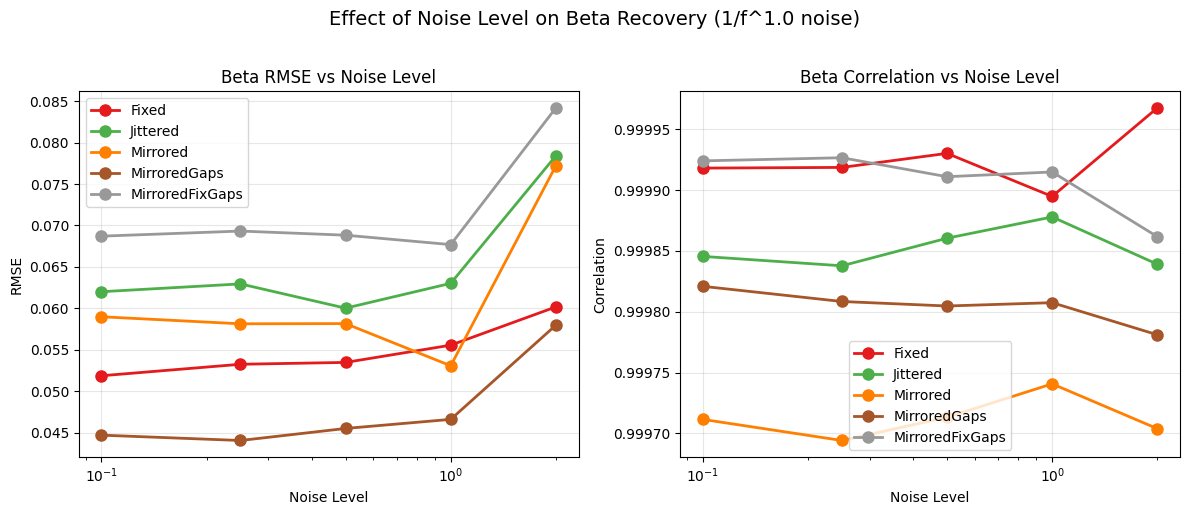

In [187]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, r) in enumerate(noise_sweep_results.items()):
    axes[0].plot(r['noise'], r['rmse'], 'o-', color=design_colors_map[i], 
                linewidth=2, markersize=8, label=name)
    axes[1].plot(r['noise'], r['corr'], 'o-', color=design_colors_map[i], 
                linewidth=2, markersize=8, label=name)

axes[0].set_xlabel('Noise Level')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Beta RMSE vs Noise Level')
axes[0].set_xscale('log')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel('Noise Level')
axes[1].set_ylabel('Correlation')
axes[1].set_title('Beta Correlation vs Noise Level')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Effect of Noise Level on Beta Recovery (1/f^{PINK_EXPONENT} noise)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Effect of Noise Color (1/f Exponent)

How does the spectral content of noise affect beta recovery?

Running noise color sweep (multi-run GLM)...
Done!


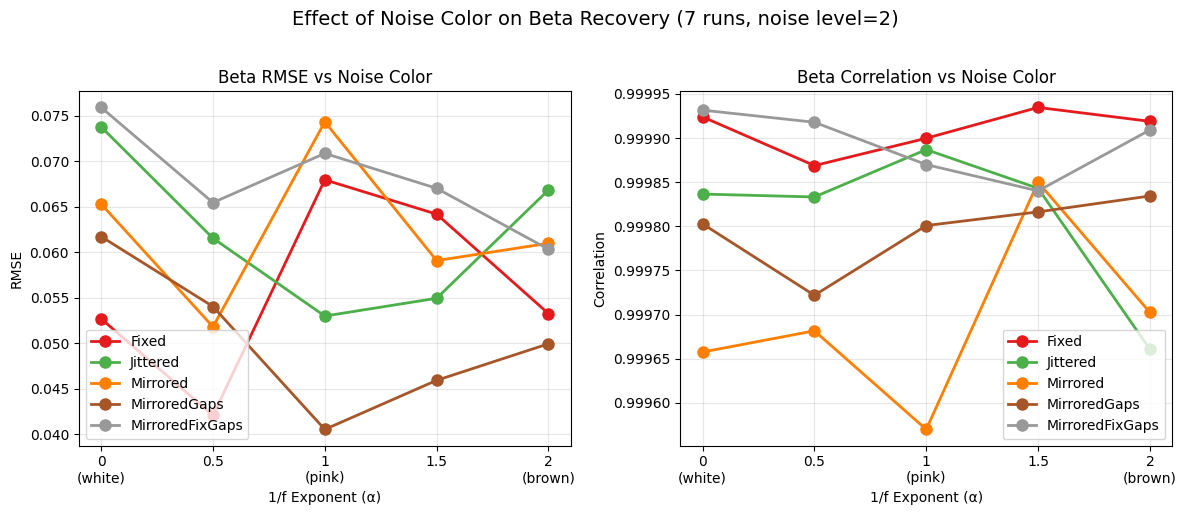


Note: Low-frequency noise (higher α) is harder for GLM to distinguish from slow BOLD fluctuations.


In [188]:
# Sweep over noise exponents (multi-run)
pink_exponents = [0.0, 0.5, 1.0, 1.5, 2.0]
color_sweep_results = {name: {'exp': [], 'rmse': [], 'corr': []} for name in designs.keys()}

print("Running noise color sweep (multi-run GLM)...")

for exp in pink_exponents:
    for name, d in designs.items():
        # Simulate multi-run with this noise color
        data, _ = simulate_multirun_data(
            d['design_sim_single'], TRUE_BETAS, N_RUNS, NOISE_LEVEL, exp, N_VOXELS
        )
        
        # Fit multi-run GLM
        results = ffs.fit_glm(
            data=data, design=d['design_full'], tr=TR, 
            max_poly_degree=None, device=device, verbose=False
        )
        
        # Metrics
        betas_est = results.betas[:, :N_EVENTS]
        m = compute_recovery_metrics(betas_est, TRUE_BETAS)
        
        color_sweep_results[name]['exp'].append(exp)
        color_sweep_results[name]['rmse'].append(m['rmse'])
        color_sweep_results[name]['corr'].append(m['correlation'])

print("Done!")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (name, r) in enumerate(color_sweep_results.items()):
    axes[0].plot(r['exp'], r['rmse'], 'o-', color=design_colors_map[i], 
                linewidth=2, markersize=8, label=name)
    axes[1].plot(r['exp'], r['corr'], 'o-', color=design_colors_map[i], 
                linewidth=2, markersize=8, label=name)

axes[0].set_xlabel('1/f Exponent (α)')
axes[0].set_ylabel('RMSE')
axes[0].set_title('Beta RMSE vs Noise Color')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(pink_exponents)
axes[0].set_xticklabels(['0\n(white)', '0.5', '1\n(pink)', '1.5', '2\n(brown)'])

axes[1].set_xlabel('1/f Exponent (α)')
axes[1].set_ylabel('Correlation')
axes[1].set_title('Beta Correlation vs Noise Color')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(pink_exponents)
axes[1].set_xticklabels(['0\n(white)', '0.5', '1\n(pink)', '1.5', '2\n(brown)'])

plt.suptitle(f'Effect of Noise Color on Beta Recovery ({N_RUNS} runs, noise level={NOISE_LEVEL})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nNote: Low-frequency noise (higher α) is harder for GLM to distinguish from slow BOLD fluctuations.")

## Conclusions

### Design Performance:
- **Lower regressor correlation** → better beta estimation
- **Jittered ISI** and **Mirrored Order** designs decorrelate regressors
- **Fixed** designs with no jitter can have high adjacent regressor correlation

### Multi-Run vs Run-Averaged GLM:
- **Multi-run GLM**: Concatenates data, uses block-diagonal polynomials per run
  - Uses all data, properly models per-run drift
  - Standard approach for fMRI analysis
- **Run-averaged GLM**: Averages data first, then fits single-run design
  - Simpler, reduces noise through averaging
  - Loses run-to-run variability information

### Adding New Designs:
1. Define a function that returns `(onsets, onset_times_dict)` for ONE run
2. Add it to `DESIGN_REGISTRY`
3. The framework automatically replicates across N_RUNS

### Key Parameters:
- `N_RUNS`: Number of independent runs (like separate fMRI scans)
- `N_REPEATS_PER_RUN`: How many cycles through all events per run
- `NOISE_LEVEL`: Controls TSNR (see TSNR guidance cell above)
- `PINK_EXPONENT`: 1/f noise color (1=pink is typical for fMRI)
- `POLY_ORDER`: Polynomial drift order per run

### Testing HRF Mismatch:
- Set `USE_DIFFERENT_HRF = True` and choose `SIMULATION_HRF_INDEX`
- This simulates with one HRF but recovers with canonical
- Tests robustness of designs to HRF misspecification